In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import scipy.stats as stats

# **Parte 1**. EDA

In [4]:
# Cargar el dataset
original_df = pd.read_csv('power_tetouan_city_original.csv')
modified_df = pd.read_csv('power_tetouan_city_modified.csv')

print(f"\n• Dataset Original cargado: {original_df.shape}")
print(f"• Dataset Modificado cargado: {modified_df.shape}")


• Dataset Original cargado: (52416, 9)
• Dataset Modificado cargado: (53464, 10)


In [5]:
# Visualizar las primeras filas del dataset original
original_df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [6]:
# Visualizar las primeras filas del dataset modificado
modified_df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,mixed_type_col
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,NaN,34055.6962,16128.87538,20240.96386,624
1,1/1/2017 0:10,6.414,74.5,0.083,0.07,0.085,29814.68354,19375.07599,20131.08434,811
2,1/1/2017 0:20,6.313,74.5,0.08,0.062,0.1,29128.10127,19006.68693,19668.43373,unknown
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,bad
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.6962,17872.34043,18442.40964,879


In [7]:
# Información del dataset original
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  object 
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [8]:
# información del dataset modificado
modified_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53464 entries, 0 to 53463
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   DateTime                   52977 non-null  object
 1   Temperature                52880 non-null  object
 2   Humidity                   52826 non-null  object
 3   Wind Speed                 52846 non-null  object
 4   general diffuse flows      52838 non-null  object
 5   diffuse flows              52849 non-null  object
 6   Zone 1 Power Consumption   52861 non-null  object
 7   Zone 2  Power Consumption  52839 non-null  object
 8   Zone 3  Power Consumption  52889 non-null  object
 9   mixed_type_col             48162 non-null  object
dtypes: object(10)
memory usage: 4.1+ MB


In [9]:
# Estadísticas descriptivas del dataset original
original_df.describe()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360


In [10]:
# Estadísticas descriptivas del dataset modificado
modified_df.describe()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,mixed_type_col
count,52977,52880,52826,52846,52838,52849,52861,52839,52889,48162
unique,52036,5446,6291,1187,11915,11923,29720,31474,25057,1002
top,NAN,?,84.6,0.082,0.055,0.115,?,error,error,unknown
freq,21,57,182,2179,1488,1196,57,50,50,5521


In [11]:
# Nombres de las columnas del dataset original
original_df.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption'],
      dtype='object')

In [12]:
# Nombres de las columnas del dataset modificado
modified_df.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption',
       'mixed_type_col'],
      dtype='object')

In [13]:
# Revisión de valores únicos por columna en el dataset original
for i in original_df.columns:
    print(i,':',original_df[i].nunique())

DateTime : 52416
Temperature : 3437
Humidity : 4443
Wind Speed : 548
general diffuse flows : 10504
diffuse flows : 10449
Zone 1 Power Consumption : 27709
Zone 2  Power Consumption : 29621
Zone 3  Power Consumption : 22838


In [14]:
# Revisión de valores únicos por columna en el dataset modificado
for i in modified_df.columns:
    print(i,':',modified_df[i].nunique())

DateTime : 52036
Temperature : 5446
Humidity : 6291
Wind Speed : 1187
general diffuse flows : 11915
diffuse flows : 11923
Zone 1 Power Consumption : 29720
Zone 2  Power Consumption : 31474
Zone 3  Power Consumption : 25057
mixed_type_col : 1002


In [15]:
# Revisión de valores nulos en el dataset original
original_df.isnull().sum()

DateTime                     0
Temperature                  0
Humidity                     0
Wind Speed                   0
general diffuse flows        0
diffuse flows                0
Zone 1 Power Consumption     0
Zone 2  Power Consumption    0
Zone 3  Power Consumption    0
dtype: int64

In [16]:
# Revisión de valores nulos en el dataset modificado
modified_df.isnull().sum()

DateTime                      487
Temperature                   584
Humidity                      638
Wind Speed                    618
general diffuse flows         626
diffuse flows                 615
Zone 1 Power Consumption      603
Zone 2  Power Consumption     625
Zone 3  Power Consumption     575
mixed_type_col               5302
dtype: int64

In [17]:
# Porcentaje de valores nulos por columna en el dataset modificado
pd.DataFrame((modified_df.isnull().mean() * 100).round(2), columns=['avg_nan'])

,avg_nan
DateTime,0.91
Temperature,1.09
Humidity,1.19
Wind Speed,1.16
general diffuse flows,1.17
diffuse flows,1.15
Zone 1 Power Consumption,1.13
Zone 2 Power Consumption,1.17
Zone 3 Power Consumption,1.08
mixed_type_col,9.92


# **Parte 2**. Preprocesamiento

In [18]:
# Copiamos el dataset modificado para trabajar con él
#cleaned_df = original_df.copy()
cleaned_df = modified_df.copy()

## Limpieza del Dataset

#### Normalizar el Nombre de las columnas

In [19]:
# Normalizar los nombres de columnas
cleaned_df.columns = (
    cleaned_df.columns
    .str.strip()                            # Quita espacios al inicio y al final
    .str.lower()                            # Convierte a minúsculas
    .str.replace(r'\s+', '_', regex=True)   # Reemplaza uno o más espacios por _
)

# Verificar resultado
print("Columnas homologadas:")
print(cleaned_df.columns.tolist())

Columnas homologadas:
['datetime', 'temperature', 'humidity', 'wind_speed', 'general_diffuse_flows', 'diffuse_flows', 'zone_1_power_consumption', 'zone_2_power_consumption', 'zone_3_power_consumption', 'mixed_type_col']


### Eliminación de Columnas Innecesarias

In [20]:
# Eliminamos la columna mixed_type_col por tener un porcentaje alto de valores nulos > al 5%
cleaned_df.drop(columns=['mixed_type_col'], inplace=True)

In [21]:
print(f"Total de Columnas: {cleaned_df.shape[1]}, Columnas: {cleaned_df.columns} ")

Total de Columnas: 9, Columnas: Index(['datetime', 'temperature', 'humidity', 'wind_speed',
       'general_diffuse_flows', 'diffuse_flows', 'zone_1_power_consumption',
       'zone_2_power_consumption', 'zone_3_power_consumption'],
      dtype='object') 


### Tratamiento de la caracteristica DateTime

In [22]:
# Filas con 'DateTime' convertible
total_total_filas = cleaned_df.shape[0]
filas_sin_datetime = cleaned_df['datetime'].isna().sum()
print(f"Filas con 'DateTime' no convertible: {filas_sin_datetime}")

# Eliminamos las filas con 'DateTime' no convertible
cleaned_df = cleaned_df[cleaned_df['datetime'].notna()] 
print("Después de eliminar filas con 'DateTime' no convertible:")   
print(f"Filas originales: {total_total_filas} ") 
print(f"Filas eliminadas: {filas_sin_datetime} ")
print(f"Total de Filas: {cleaned_df.shape[0]} ")

Filas con 'DateTime' no convertible: 487
Después de eliminar filas con 'DateTime' no convertible:
Filas originales: 53464 
Filas eliminadas: 487 
Total de Filas: 52977 


In [23]:
# Limpieza de espacios en blanco en la columna 'datetime'
cleaned_df['datetime'] = cleaned_df['datetime'].astype(str).str.strip()

# Parsear la columna 'datetime' a formato datetime
cleaned_df['datetime_parsed'] = pd.to_datetime(cleaned_df['datetime'], format='%m/%d/%Y %H:%M', errors='coerce')

# Verificar filas con 'datetime_parsed' no convertible
invalid_rows = cleaned_df[cleaned_df['datetime_parsed'].isna()]
print(f"Filas con 'datetime_parsed' no convertible: {invalid_rows.shape[0]}")

# Elimina datetime_parced no convertible
total_total_filas = cleaned_df.shape[0]
cleaned_df = cleaned_df[cleaned_df['datetime_parsed'].notna()]
print("Después de eliminar filas con 'datetime_parsed' no convertible:")   
print(f"Filas originales: {total_total_filas} ") 
print(f"Filas eliminadas: {invalid_rows.shape[0]} ")
print(f"Total de Filas: {cleaned_df.shape[0]} ")


Filas con 'datetime_parsed' no convertible: 21
Después de eliminar filas con 'datetime_parsed' no convertible:
Filas originales: 52977 
Filas eliminadas: 21 
Total de Filas: 52956 


In [24]:
# Se reemplazar la columna original con la columna datetime_parsed
cleaned_df['datetime'] = cleaned_df['datetime_parsed']

# Eliminación de la columna temporal datetime_parsed
cleaned_df.drop(columns=['datetime_parsed'], inplace=True)

# Ordenamiento del DataFrame por la columna 'datetime' y reinicio de los índices
cleaned_df = cleaned_df.sort_values('datetime')
cleaned_df.reset_index(drop=True, inplace=True)

# Verificación de la estructura final
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52956 entries, 0 to 52955
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   datetime                  52956 non-null  datetime64[ns]
 1   temperature               52377 non-null  object        
 2   humidity                  52324 non-null  object        
 3   wind_speed                52342 non-null  object        
 4   general_diffuse_flows     52334 non-null  object        
 5   diffuse_flows             52346 non-null  object        
 6   zone_1_power_consumption  52356 non-null  object        
 7   zone_2_power_consumption  52337 non-null  object        
 8   zone_3_power_consumption  52386 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 3.6+ MB


### Tratamiento de los caracteristicas númericas

In [25]:
# Identificar las columnas tipo 'object', excluyendo 'datetime'
object_cols = cleaned_df.select_dtypes(include=['object']).columns
numeric_cols = list(filter(lambda col: col != 'datetime', object_cols))

# Convertir esas columnas a tipo float (maneja errores con coerción)
for col in numeric_cols:        
    cleaned_df[col] = pd.to_numeric(cleaned_df[col], errors='coerce')

# Verificar los tipos de datos resultantes
cleaned_df.reset_index(drop=True, inplace=True)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52956 entries, 0 to 52955
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   datetime                  52956 non-null  datetime64[ns]
 1   temperature               52172 non-null  float64       
 2   humidity                  52129 non-null  float64       
 3   wind_speed                52164 non-null  float64       
 4   general_diffuse_flows     52137 non-null  float64       
 5   diffuse_flows             52154 non-null  float64       
 6   zone_1_power_consumption  52160 non-null  float64       
 7   zone_2_power_consumption  52178 non-null  float64       
 8   zone_3_power_consumption  52216 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.6 MB


#### Manejo de NANs para Columnas Númericas

In [26]:
# conteo de datos nulos por columna después de la conversión
cleaned_df.isna().sum()

datetime                      0
temperature                 784
humidity                    827
wind_speed                  792
general_diffuse_flows       819
diffuse_flows               802
zone_1_power_consumption    796
zone_2_power_consumption    778
zone_3_power_consumption    740
dtype: int64

In [27]:
# Porcentaje de valores nulos por columna en el dataset modificado
pd.DataFrame((cleaned_df.isnull().mean() * 100).round(2), columns=['avg_nan'])

,avg_nan
datetime,0.00
temperature,1.48
humidity,1.56
wind_speed,1.50
general_diffuse_flows,1.55
diffuse_flows,1.51
zone_1_power_consumption,1.50
zone_2_power_consumption,1.47
zone_3_power_consumption,1.40


In [28]:
# Generar la media móvil (centrada o no)
def generar_media_movil(s: pd.Series, window: int = 3, center: bool = True, min_periods: int = 1) -> pd.Series:
    """
    Devuelve la serie de media móvil (rolling mean) de `s`.
    - window: tamaño de ventana en número de filas (p.ej., 3 => anterior, actual y siguiente si center=True)
    - center: True para ventana centrada; False para usar sólo pasado (útil en escenarios causales)
    - min_periods: mínimo de observaciones requeridas dentro de la ventana
    """
    return s.rolling(window=window, center=center, min_periods=min_periods).mean()

In [29]:
# Imputar NaNs usando la media móvil precomputada
def imputar_nans_con_media_movil(s: pd.Series, media_movil: pd.Series) -> pd.Series:
    """
    Reemplaza los NaN de `s` con los valores correspondientes de `media_movil`.
    Mantiene alineación por índice.
    """
    return s.fillna(media_movil)

In [30]:
# Cálculo de la ventana (en función del intervalo de 10 minutos)
# Cada hora tiene 60/10 = 6 registros.
# 1 hora = 6
# 3 horas = 18
# 6 horas =	36
# 12 horas = 72
# 24 horas = 144

WINDOW = 8640
CENTER = True
MIN_PERIODS = 1

for col in numeric_cols:
    # Media móvil
    media_movil = generar_media_movil(cleaned_df[col], window=WINDOW, center=CENTER, min_periods=MIN_PERIODS)

    # Imputar NaNs con media móvil
    cleaned_df[col] = imputar_nans_con_media_movil(cleaned_df[col], media_movil)

    
print("Imputación completada.")
cleaned_df.head()

Imputación completada.


,datetime,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone_1_power_consumption,zone_2_power_consumption,zone_3_power_consumption
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,97.02432,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.08500,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.10000,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.09600,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.08500,27335.69620,17872.34043,18442.40964


In [31]:
# Porcentaje de valores nulos por columna en el dataset modificado
pd.DataFrame((cleaned_df.isnull().mean() * 100).round(2), columns=['avg_nan'])

,avg_nan
datetime,0.0
temperature,0.0
humidity,0.0
wind_speed,0.0
general_diffuse_flows,0.0
diffuse_flows,0.0
zone_1_power_consumption,0.0
zone_2_power_consumption,0.0
zone_3_power_consumption,0.0


In [32]:
print("\nDataFrame con NaN rellenados por la media móvil:")
cleaned_df.head(10)


DataFrame con NaN rellenados por la media móvil:


,datetime,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone_1_power_consumption,zone_2_power_consumption,zone_3_power_consumption
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,97.02432,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.08500,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.10000,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.09600,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.08500,27335.69620,17872.34043,18442.40964
5,2017-01-01 00:50:00,5.853,76.9,0.081,0.059,0.10800,26624.81013,17416.41337,18130.12048
6,2017-01-01 01:00:00,5.641,77.7,0.080,0.048,0.09600,25998.98734,16993.31307,17945.06024
7,2017-01-01 01:10:00,5.496,78.2,0.085,0.055,0.09300,25446.07595,16661.39818,17459.27711
8,2017-01-01 01:20:00,5.678,78.1,0.081,0.066,0.14100,24777.72152,16227.35562,17025.54217
9,2017-01-01 01:30:00,5.491,77.3,0.082,0.062,0.11100,24279.49367,15939.20973,16794.21687


In [33]:
total_filas = len(cleaned_df)
# Elimina registros con un porcentaje menor a 5% mínimo de valores que sean NaN        
cleaned_df.dropna(subset=pd.DataFrame(cleaned_df.isnull().mean()*100, columns=['avg_nan'])
                                .query('avg_nan < 5').index, inplace=True)
cleaned_df.reset_index(drop=True, inplace=True)
# Reporte final
print("\nDespués de eliminar filas con valores no convertibles:")
print(f"Filas originales: {total_filas}")
print(f"Filas eliminadas: {total_filas-cleaned_df.shape[0]}")
print(f"Filas restantes: {cleaned_df.shape[0]}")


Después de eliminar filas con valores no convertibles:
Filas originales: 52956
Filas eliminadas: 0
Filas restantes: 52956


In [34]:
# Verificación de la estructura final
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52956 entries, 0 to 52955
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   datetime                  52956 non-null  datetime64[ns]
 1   temperature               52956 non-null  float64       
 2   humidity                  52956 non-null  float64       
 3   wind_speed                52956 non-null  float64       
 4   general_diffuse_flows     52956 non-null  float64       
 5   diffuse_flows             52956 non-null  float64       
 6   zone_1_power_consumption  52956 non-null  float64       
 7   zone_2_power_consumption  52956 non-null  float64       
 8   zone_3_power_consumption  52956 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.6 MB


### Manejo de Valores Atípicos

In [35]:
cleaned_df.describe()

,datetime,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone_1_power_consumption,zone_2_power_consumption,zone_3_power_consumption
count,52956,52956.000000,52956.000000,52956.000000,52956.000000,52956.000000,5.295600e+04,5.295600e+04,5.295600e+04
mean,2017-07-02 00:41:07.969634816,27.505285,91.868654,5.544118,227.313238,99.875001,4.251846e+04,2.637416e+04,2.282049e+04
min,2017-01-01 00:00:00,3.247000,11.340000,0.050000,0.004000,0.011000,1.389570e+04,8.560081e+03,5.935174e+03
25%,2017-04-01 22:17:30,14.520000,58.640000,0.078000,0.066000,0.122000,2.647764e+04,1.706853e+04,1.321824e+04
50%,2017-07-02 02:05:00,19.000000,70.400000,0.086000,9.530000,8.380000,3.248217e+04,2.096021e+04,1.648161e+04
75%,2017-10-01 01:42:30,23.210000,82.100000,4.916000,325.600000,105.600000,3.768558e+04,2.492696e+04,2.196008e+04
max,2017-12-30 23:50:00,28149.240000,118972.800000,14337.903000,69797.000000,44602.800000,4.559947e+07,2.958428e+06,3.566782e+06
std,NaN,162.177597,593.047263,76.938155,1225.793191,571.787948,2.454010e+05,8.845397e+04,8.232745e+04


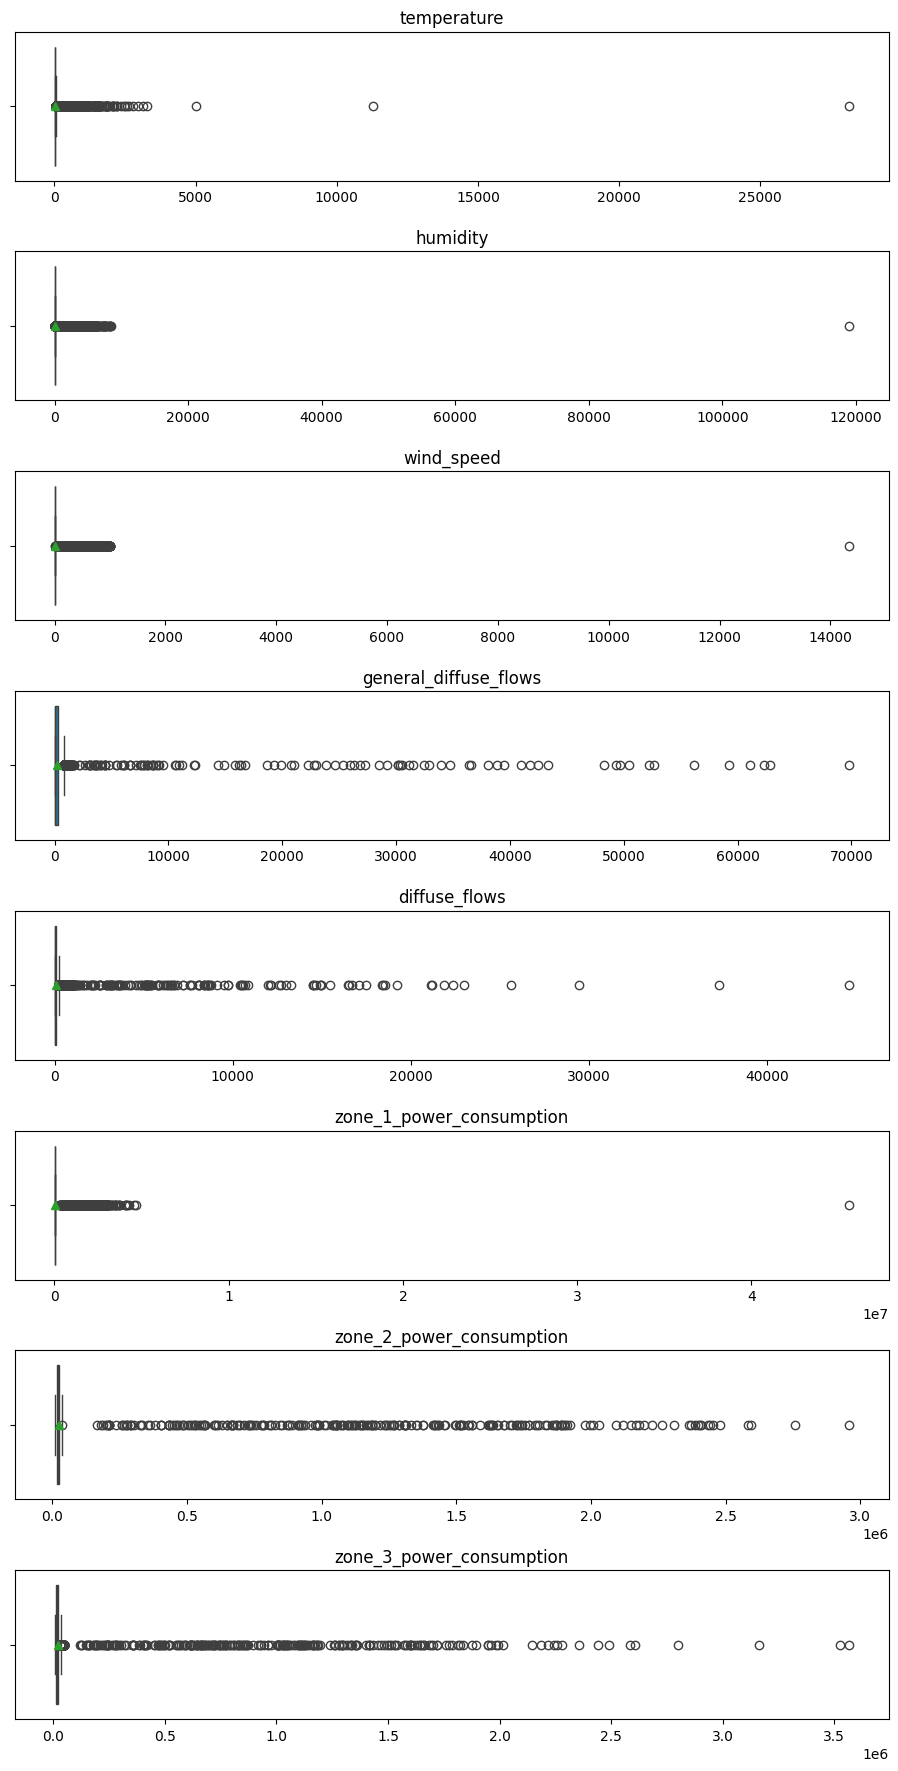

In [36]:
# Se realiza las graficas de boxplot para visualizar outliers
fig, axes = plt.subplots(len(numeric_cols),1, figsize=(10,18))
plt.subplots_adjust(wspace=0.3)
plt.tight_layout(pad=3.0)

axes = axes.ravel()
for col, ax in zip(cleaned_df[numeric_cols], axes):
  sns.boxplot(x=cleaned_df[col], ax=ax, showmeans=True)
  ax.set(title=f'{col}', xlabel=None)

In [37]:
# Skewness de los datos usando la funcion skew()
cleaned_df.skew(numeric_only = True)

temperature                 108.189382
humidity                    154.255611
wind_speed                  125.272242
general_diffuse_flows        34.339523
diffuse_flows                35.202485
zone_1_power_consumption    124.589067
zone_2_power_consumption     19.458924
zone_3_power_consumption     20.892969
dtype: float64

In [38]:
# Kurtosis de los datos usando la funcion kurt()
cleaned_df.kurt(numeric_only = True)

temperature                 17557.057292
humidity                    30513.917375
wind_speed                  22772.275610
general_diffuse_flows        1391.068154
diffuse_flows                1723.312873
zone_1_power_consumption    22473.840664
zone_2_power_consumption      418.401194
zone_3_power_consumption      526.441646
dtype: float64

In [39]:
# Se genera una funcion para el calculo de los outliers
def outliers(df, str_att_name, method, replace=True,replace_metric=None,
             ma_window: int = 3, ma_center: bool = True, ma_min_periods: int = 1,
             use_ewm: bool = False, ewm_span: int = 3,             
             limit_side: str = "both"   # "lower" | "upper" | "both"
             ):
  
  # Verifica si la columna existe en el DataFrame
  if str_att_name not in df.columns:
        raise ValueError(f"La columna '{str_att_name}' no existe en el DataFrame.")
  
  # Validar limit_side
  if limit_side not in ("lower", "upper", "both"):
      raise ValueError("limit_side inválido. Usa 'lower', 'upper' o 'both'.")

  # --- detección de outliers ---
  if method == 'IQR':
    # Se calcula el valor inter-cuartil
    percentile_Q1 = df[str_att_name].quantile(0.25)
    percentile_Q3 = df[str_att_name].quantile(0.75)
    iqr = percentile_Q3 - percentile_Q1
    # Se establece limite superior e inferior
    upper_limit = percentile_Q3 + 1.5 * iqr
    lower_limit = percentile_Q1 - 1.5 * iqr
    # Máscaras por lado
    mask_lower = df[str_att_name] < lower_limit
    mask_upper = df[str_att_name] > upper_limit
    if limit_side == "lower":
        mask = mask_lower
    elif limit_side == "upper":
        mask = mask_upper
    else:  # "both"
        mask = mask_lower | mask_upper
    # Se determinan los valores atípicos en un nuevo dataframe
    outliers = df[mask]

  elif  method == 'zscore':
    # Calcula el z-score (tolerante a NaN) y alinea con el índice
    z = stats.zscore(df[str_att_name], nan_policy='omit')
    z = pd.Series(z, index=df.index)
    threshold = 3
    # Máscaras por lado (nota: z puede ser NaN en posiciones con NaN en la serie original)
    if limit_side == "lower":
        mask = (z < -threshold)
    elif limit_side == "upper":
        mask = (z > threshold)
    else:  # "both"
        mask = (z.abs() > threshold)
    mask = mask.fillna(False)
    outliers = df[mask]
  else:
    print('Metodo no valido :  {} %'.format(method))
    return  # Importante: salir para evitar errores posteriores

  if  method == 'IQR' or method == 'zscore':
    print('Total de registros del atrubuto {}:  {:.3f}'.format(str_att_name,(df[str_att_name].shape[0])))
    print('Total de outliers del atrubuto {}:  {:.3f}'.format(str_att_name,(outliers[str_att_name].shape[0])))
    print('Porcentage del atributo {}:  {:.3f} %'.format(str_att_name,(outliers[str_att_name].shape[0]*100) / df[str_att_name].shape[0]))
    
    if outliers.empty:
      print('No se encontraron outliers para los límites seleccionados. No se realizaron cambios.')
      return

    if replace == True and replace_metric is not None:
      # Reemplaza los outliers por un valor especifico
      if replace_metric == 'mean':
        replace_value = df[str_att_name].mean()

      elif replace_metric == 'median':
        replace_value = df[str_att_name].median()

      elif replace_metric == 'mode':
        moda = df[str_att_name].mode(dropna=True)
        replace_value = moda.iloc[0] if len(moda) > 0 else df[str_att_name].median()

      elif replace_metric == 'movavg':
        # --- media móvil local por fila ---
        if use_ewm:
            ma = df[str_att_name].ewm(span=ewm_span, adjust=False, min_periods=1).mean()
            ma_label = f"ewm(span={ewm_span})"
        else:
            ma = df[str_att_name].rolling(window=ma_window, center=ma_center, min_periods=ma_min_periods).mean()
            ma_label = f"rolling(window={ma_window}, center={ma_center})"
        # Fallback para posiciones donde la MA sea NaN (bordes/gaps)
        fallback = df[str_att_name].median()
        # Valores de MA solo en los índices outliers; rellenar NaN con fallback
        replace_value = ma.reindex(df.index).loc[outliers.index].fillna(fallback)
        print(f"Outliers del atributo {str_att_name} reemplazados por media móvil {ma_label}. (limit_side='{limit_side}')")

      else:
        print('replace_metric no válido. Usa: mean | median | mode | movavg')
        return
        
      # Se reemplazan los outliers con la métrica seleccionada
      df.loc[outliers.index, str_att_name] = replace_value
      
      # Evitar imprimir un objeto enorme si es movavg (Series)
      if replace_metric == 'movavg':
        print('Outliers del atributo {} reemplazados usando media móvil ({}). Total reemplazados: {}'.format(
            str_att_name, ma_label, len(outliers.index)))
      else:
        print('Outliers del atributo {} reemplazados por:  {}'.format(str_att_name, replace_value))

    else:     
      # Elimina outliers del dataframe
      df.drop(outliers.index.to_list(), inplace=True)
      print('Outliers del atributo {} eliminados'.format(str_att_name))


In [40]:
# Calculo del porcentaje de outliers por cada variable númerica
for col in numeric_cols:
    print('Outlier Analysis for {}:'.format(col))
    outliers(cleaned_df,str(col),'IQR', limit_side="upper", replace=True,replace_metric='movavg', 
             ma_window=WINDOW, ma_center=CENTER, ma_min_periods=MIN_PERIODS)
    print(80*'-')  

Outlier Analysis for temperature:
Total de registros del atrubuto temperature:  52956.000
Total de outliers del atrubuto temperature:  691.000
Porcentage del atributo temperature:  1.305 %
Outliers del atributo temperature reemplazados por media móvil rolling(window=8640, center=True). (limit_side='upper')
Outliers del atributo temperature reemplazados usando media móvil (rolling(window=8640, center=True)). Total reemplazados: 691
--------------------------------------------------------------------------------
Outlier Analysis for humidity:
Total de registros del atrubuto humidity:  52956.000
Total de outliers del atrubuto humidity:  557.000
Porcentage del atributo humidity:  1.052 %
Outliers del atributo humidity reemplazados por media móvil rolling(window=8640, center=True). (limit_side='upper')
Outliers del atributo humidity reemplazados usando media móvil (rolling(window=8640, center=True)). Total reemplazados: 557
-------------------------------------------------------------------

In [41]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52956 entries, 0 to 52955
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   datetime                  52956 non-null  datetime64[ns]
 1   temperature               52956 non-null  float64       
 2   humidity                  52956 non-null  float64       
 3   wind_speed                52956 non-null  float64       
 4   general_diffuse_flows     52956 non-null  float64       
 5   diffuse_flows             52956 non-null  float64       
 6   zone_1_power_consumption  52956 non-null  float64       
 7   zone_2_power_consumption  52956 non-null  float64       
 8   zone_3_power_consumption  52956 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.6 MB


In [42]:
# Transformacion Logaritmica para variables con distribucion sesgada a la derecha
cleaned_df['general_diffuse_flows'] = np.log(cleaned_df['general_diffuse_flows'])
cleaned_df['diffuse_flows'] = np.log(cleaned_df['diffuse_flows'])
cleaned_df['wind_speed'] = np.log(cleaned_df['wind_speed'])
cleaned_df.head()

,datetime,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone_1_power_consumption,zone_2_power_consumption,zone_3_power_consumption
0,2017-01-01 00:00:00,6.559,73.8,-2.488915,-2.975930,4.574962,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,-2.488915,-2.659260,-2.465104,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,-2.525729,-2.780621,-2.302585,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,-2.488915,-2.396896,-2.343407,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,-2.513306,-3.036554,-2.465104,27335.69620,17872.34043,18442.40964


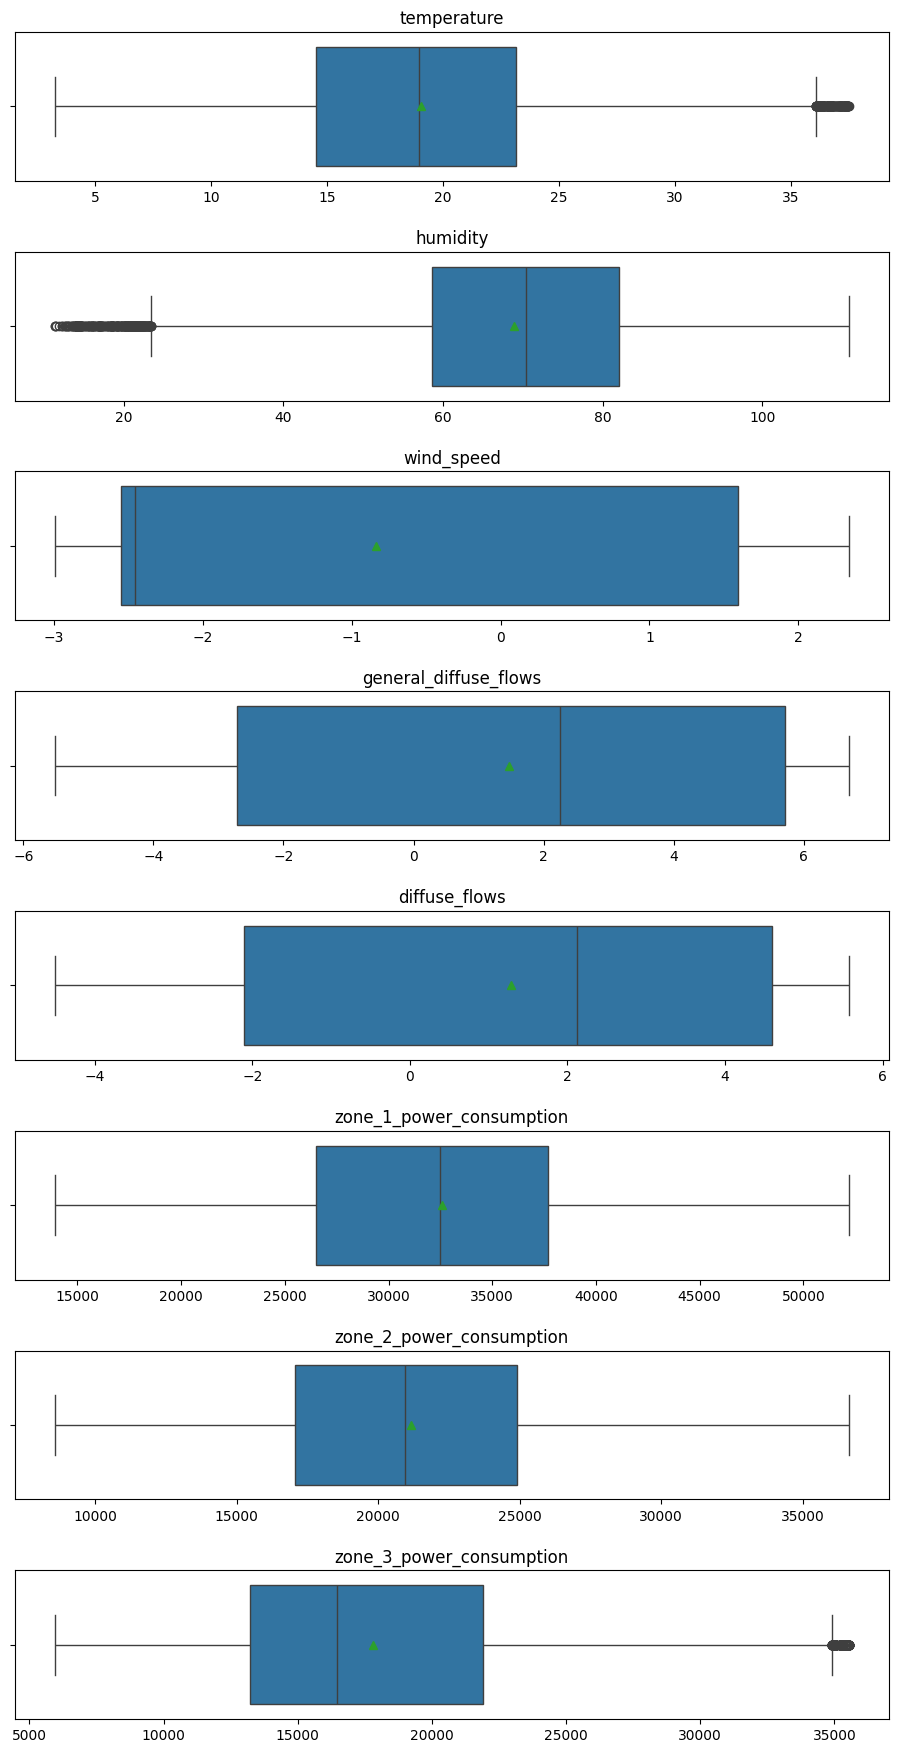

In [43]:
# Se realiza las graficas de boxplot para visualizar outliers
fig, axes = plt.subplots(len(numeric_cols),1, figsize=(10,18))
plt.subplots_adjust(wspace=0.3)
plt.tight_layout(pad=3.0)

axes = axes.ravel()
for col, ax in zip(cleaned_df[numeric_cols], axes):
  sns.boxplot(x=cleaned_df[col], ax=ax, showmeans=True)
  ax.set(title=f'{col}', xlabel=None)

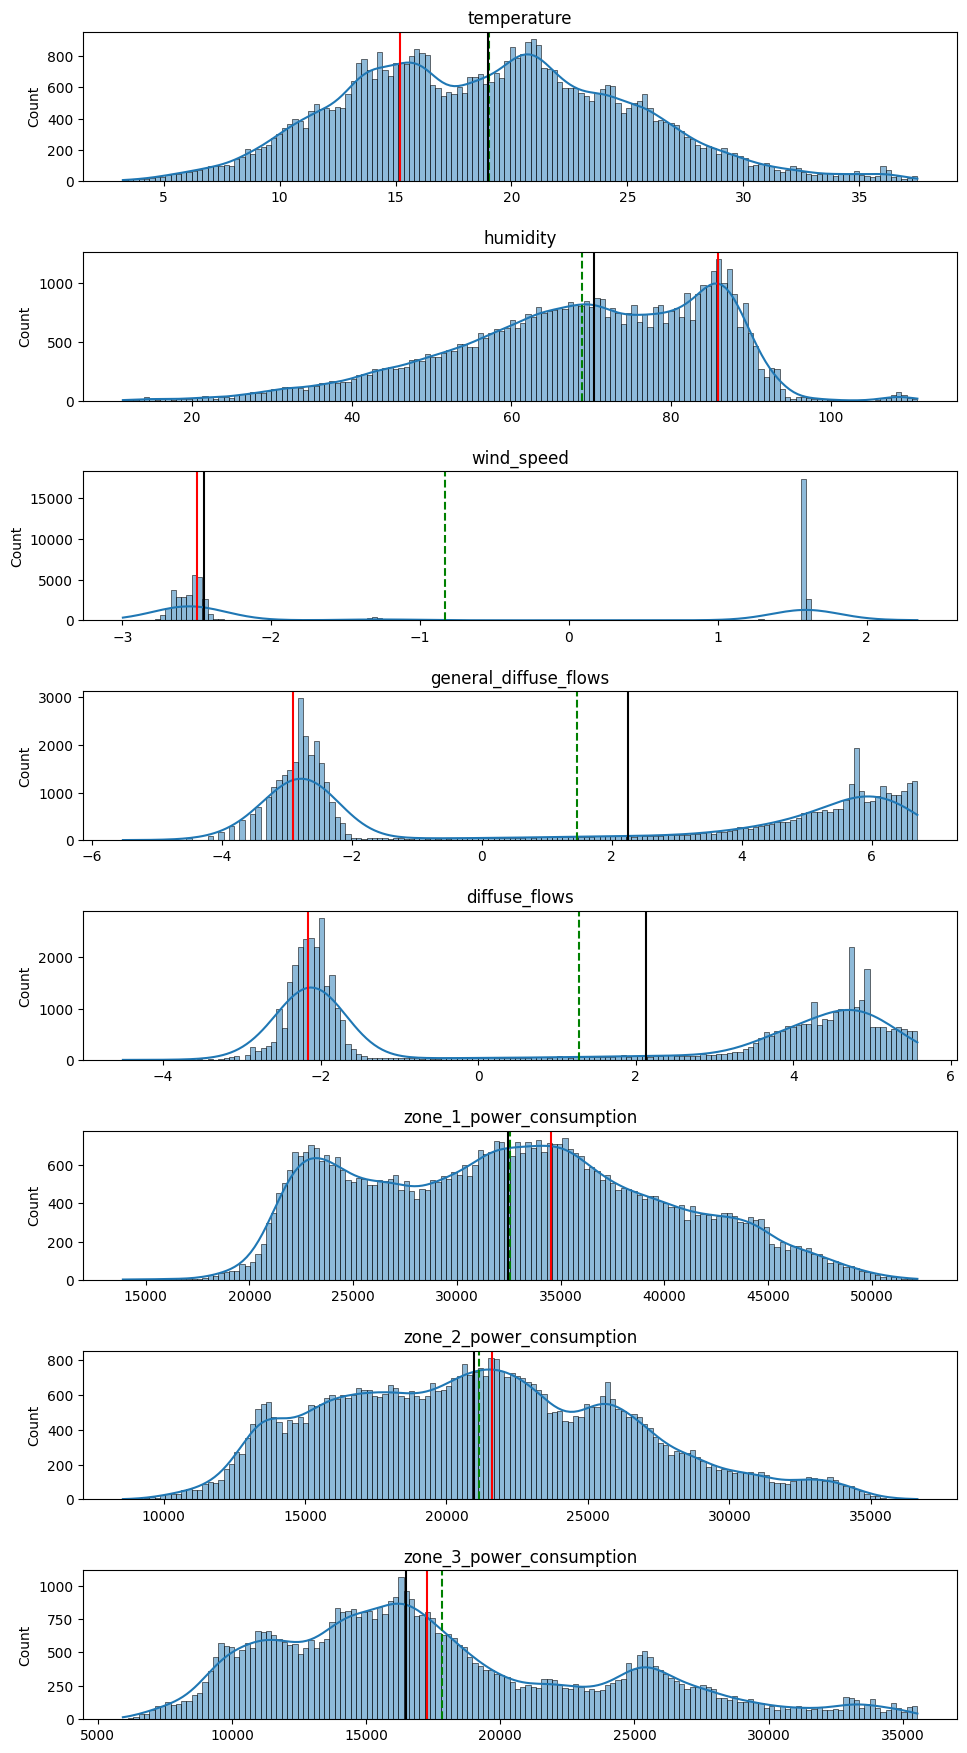

In [44]:
# Se Genera un grafico Matplotlib y Seaborn
fig, axes = plt.subplots(len(numeric_cols),1, figsize=(10,18))
plt.subplots_adjust(wspace=0.3)
plt.tight_layout(pad=3.0)
axes = axes.ravel()

# Se genera un histograma con la media, mediana y moda para una mejor visualizacion
for col, ax in zip(cleaned_df[numeric_cols], axes):
  sns.histplot(x=cleaned_df[col], ax=ax, kde=True, bins=150)
  ax.set(title=f'{col}', xlabel=None)
  ax.ticklabel_format(useOffset=False, style='plain', axis='y')   #y-axis scientific notation turned off
  ax.ticklabel_format(useOffset=False, style='plain', axis='x')   #x-axis scientific notation turned off
  ax.axvline(x=cleaned_df[col].mean(), color='green', linestyle='--')
  ax.axvline(x=cleaned_df[col].median(), color='black', linestyle='-')
  ax.axvline(x=cleaned_df[col].mode().values[0], color='red', linestyle='-')

# **Parte 3**. Ingeniería de Características

In [45]:
data = cleaned_df.copy()

Text(0, 0.5, 'temperature')

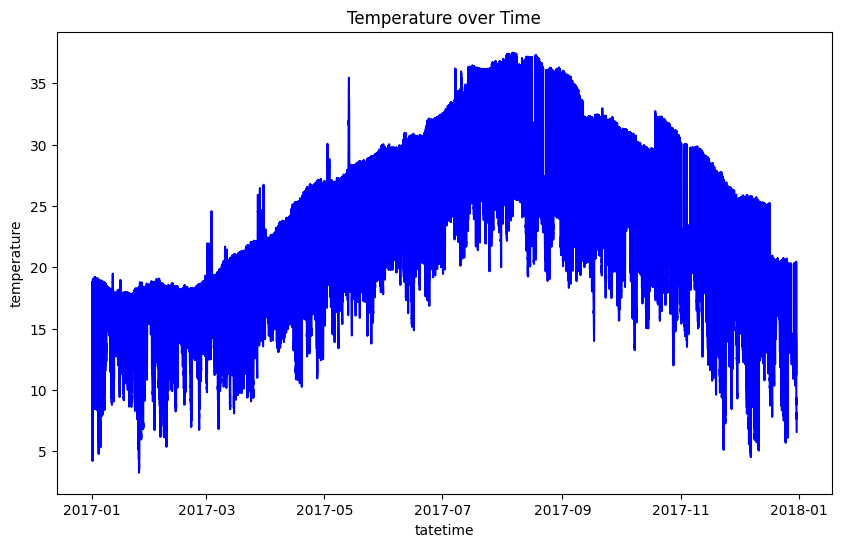

In [46]:
# Temperature
plt.figure(figsize=(10,6))
plt.plot(data['datetime'], data['temperature'], color='blue')
plt.title('Temperature over Time')
plt.xlabel('tatetime')
plt.ylabel('temperature')

Text(0, 0.5, 'humidity')

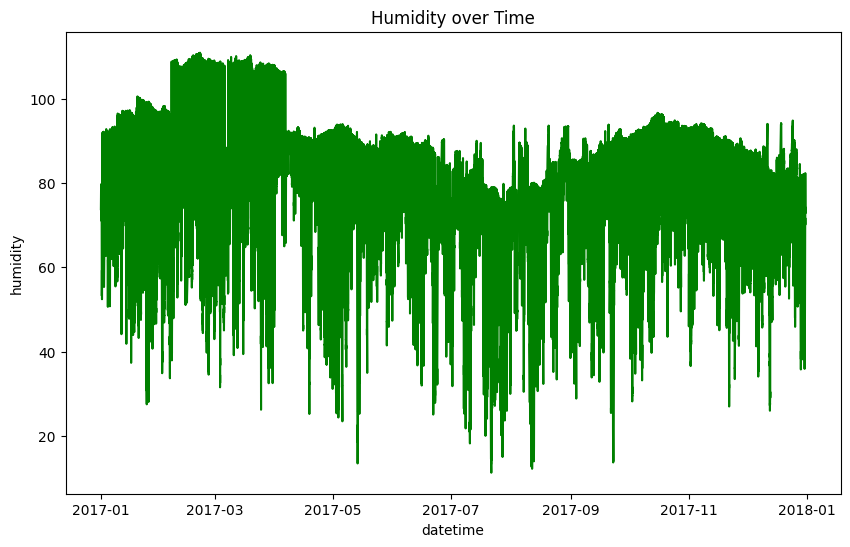

In [47]:
# Humidity
plt.figure(figsize=(10,6))
plt.plot(data['datetime'], data['humidity'], color='green')
plt.title('Humidity over Time')
plt.xlabel('datetime')
plt.ylabel('humidity')

In [48]:
# Lista de columnas de zonas
zones = ['zone_1_power_consumption',
         'zone_2_power_consumption',
         'zone_3_power_consumption']

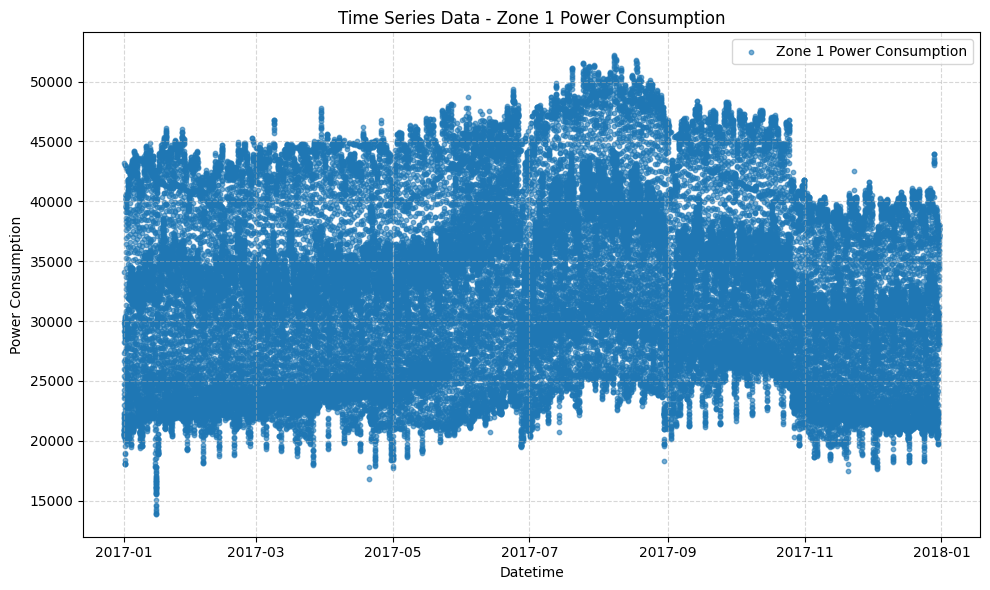

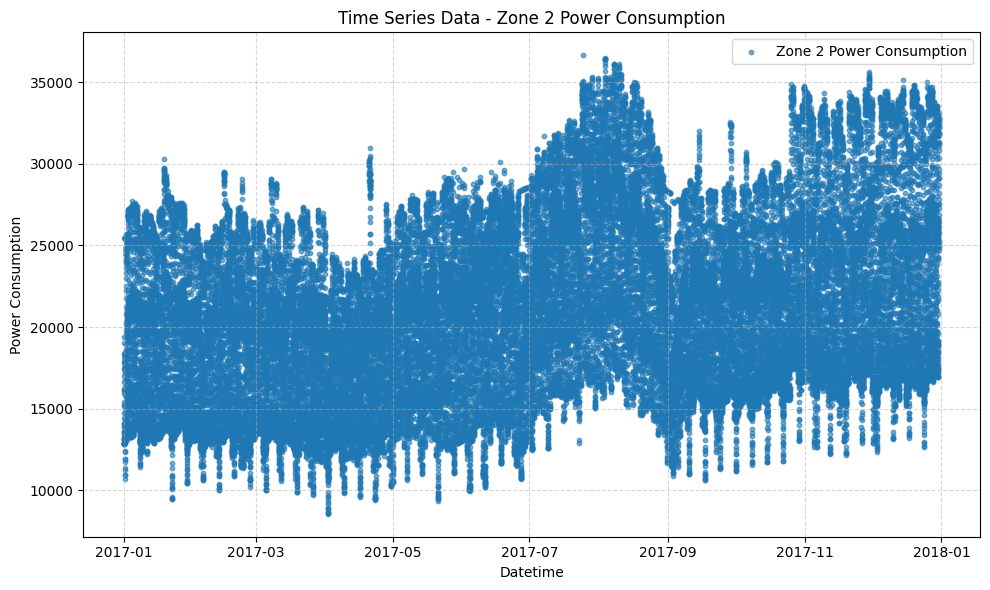

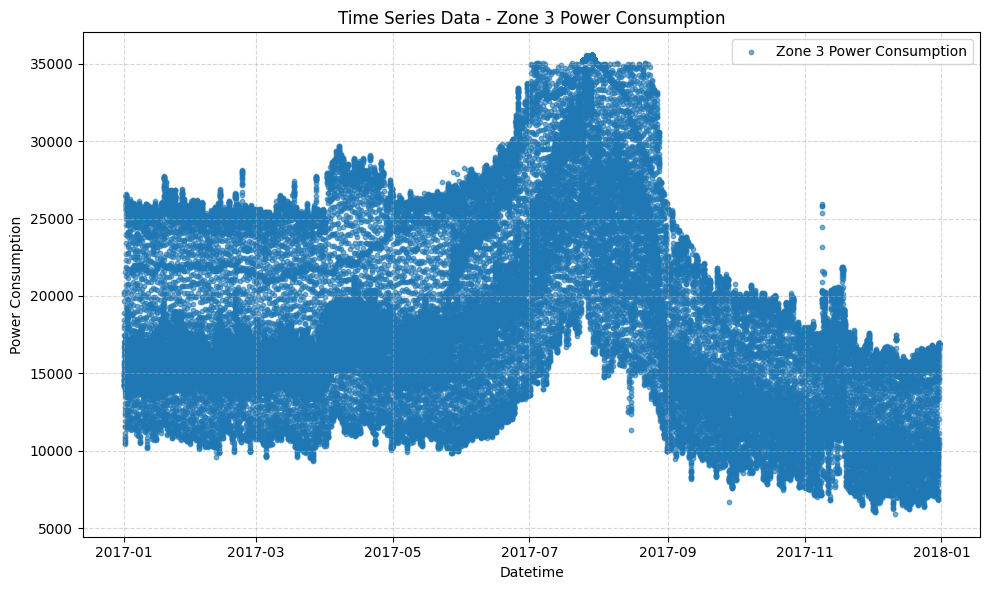

In [49]:
# Loop para graficar cada zona - Power Consumption 
for zone in zones:
    plt.figure(figsize=(10, 6))
    plt.scatter(
        cleaned_df['datetime'],
        cleaned_df[zone],
        label=zone.replace('_', ' ').title(),
        alpha=0.6,
        s=10  # tamaño de los puntos
    )
    
    # Etiquetas y título automáticos
    plt.xlabel('Datetime')
    plt.ylabel('Power Consumption')
    plt.title(f'Time Series Data - {zone.replace("_", " ").title()}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

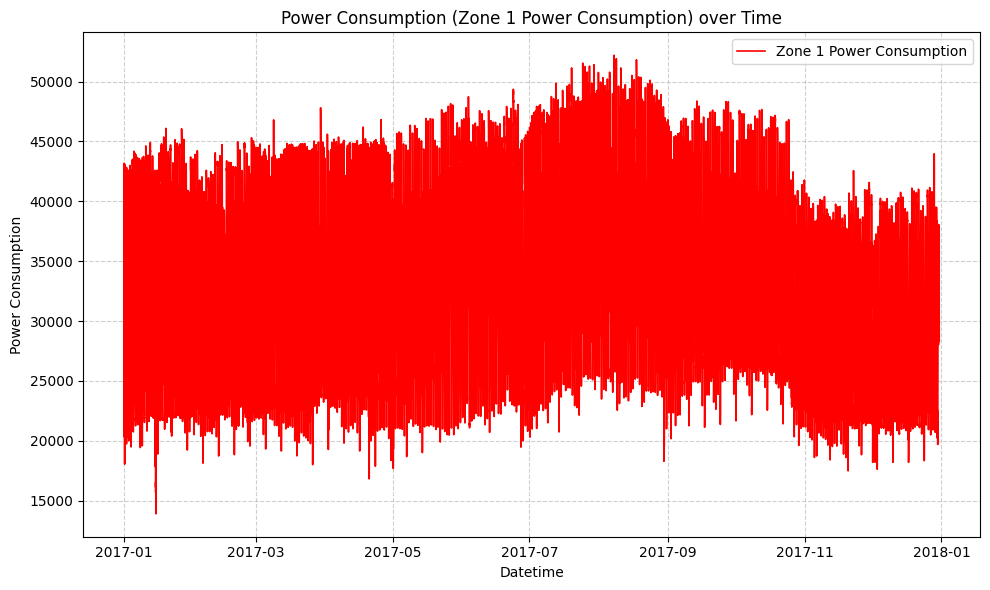

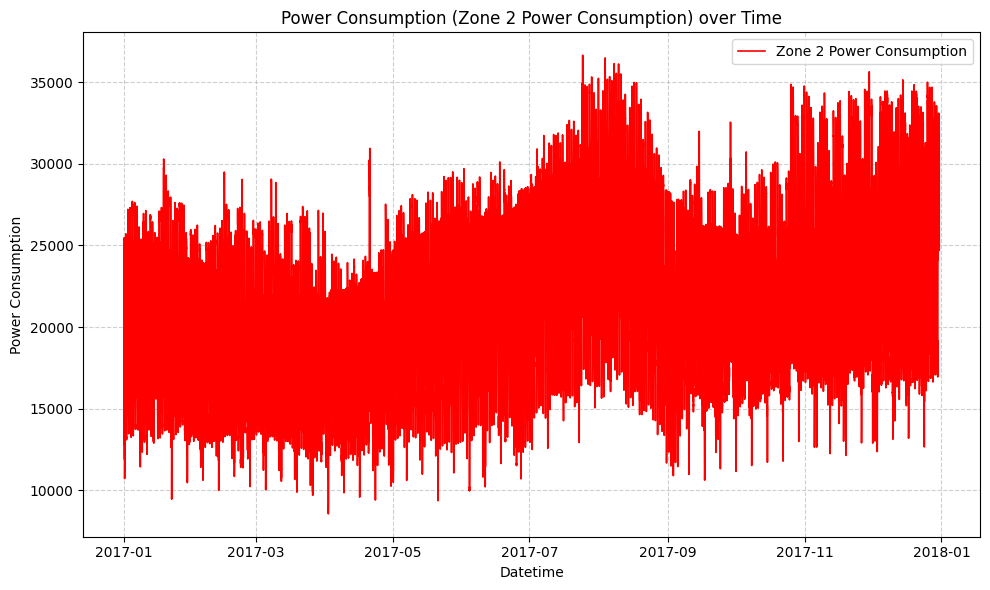

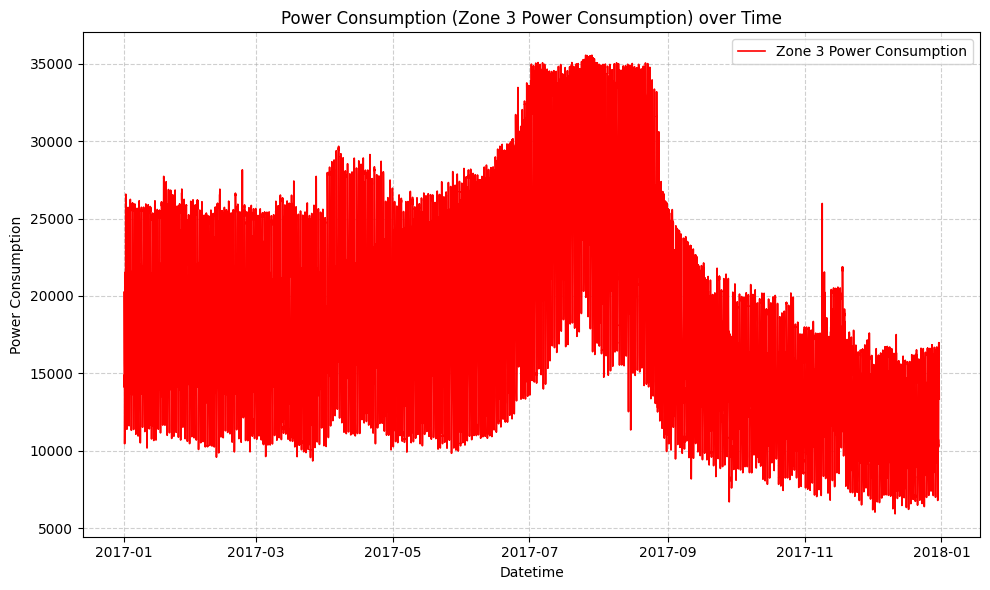

In [50]:
# Loop para graficar cada zona - Power Consumption Sobre linea de tiempo
for zone in zones:
    plt.figure(figsize=(10, 6))
    plt.plot(cleaned_df['datetime'], 
             cleaned_df[zone], 
             label=zone.replace('_', ' ').title(), 
             linewidth=1.2, color='red')
    plt.title(f"Power Consumption ({zone.replace('_', ' ').title()}) over Time")
    plt.xlabel('Datetime')
    plt.ylabel('Power Consumption')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

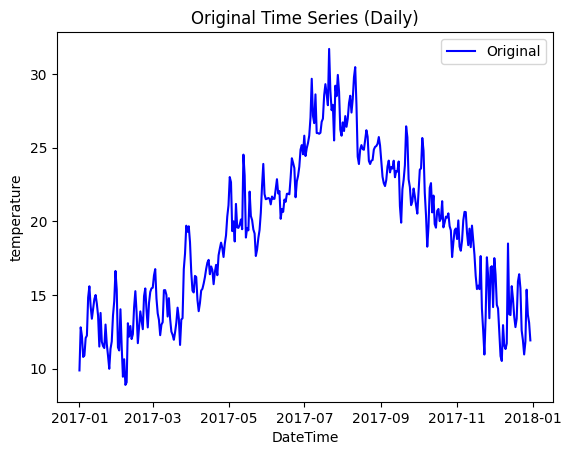

In [51]:
from statsmodels.tsa.seasonal import STL

# Se asume que la columna 'datetime' ya está en formato datetime
variable_of_interest = 'temperature'
df_resampled = data.set_index('datetime').resample('D').mean()

# Se relaiza la descomposición STL sobre los datos re-muestreados
stl_result = STL(df_resampled[variable_of_interest], seasonal=13).fit()

# Grafica de las series de tiempo originales
plt.plot(df_resampled.index, df_resampled[variable_of_interest], label='Original', color='blue')
plt.title('Original Time Series (Daily)')
plt.xlabel('DateTime')
plt.ylabel(variable_of_interest)
plt.legend()

In [52]:
df_resampled

,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone_1_power_consumption,zone_2_power_consumption,zone_3_power_consumption
datetime,,,,,,,,
2017-01-01,9.874201,68.805158,-2.218467,0.704669,0.452493,28791.730217,18015.004678,17851.026818
2017-01-02,12.801479,72.107368,-2.420727,0.904490,0.542753,29438.303071,19737.875816,17924.380930
2017-01-03,12.213072,75.236615,-2.492451,0.735730,0.650523,30742.668623,20335.291775,17619.717050
2017-01-04,10.789605,75.689614,-2.444733,0.756239,0.392756,30730.249224,20221.466641,17651.886660
2017-01-05,10.891893,71.572758,-2.346551,0.767894,0.594505,31394.549765,20171.099090,17758.623949
...,...,...,...,...,...,...,...,...
2017-12-26,11.815636,70.042186,-2.435893,0.442198,0.717173,30041.439997,25007.283384,11527.577096
2017-12-27,15.358054,59.621993,-2.313775,0.266461,0.461572,30056.959928,25225.779112,11594.117186
2017-12-28,13.656712,63.259092,-2.426891,0.609692,0.627775,30353.679132,24610.263926,11240.914275


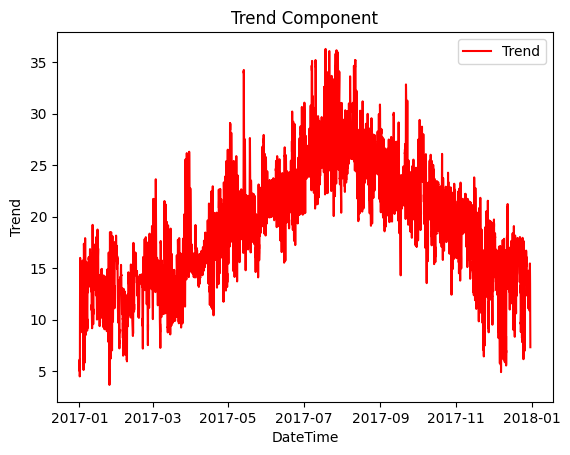

In [53]:
#Se realiza la descomposición estacional usando STL
from statsmodels.tsa.seasonal import seasonal_decompose

# Se realiza la descomposición estacional usando seasonal_decompose
result = seasonal_decompose(data.set_index('datetime')[variable_of_interest], model='additive', period=13)

plt.plot(data['datetime'], result.trend, label='Trend', color='red')
plt.title('Trend Component')
plt.xlabel('DateTime')
plt.ylabel('Trend')
plt.legend()

In [54]:
result

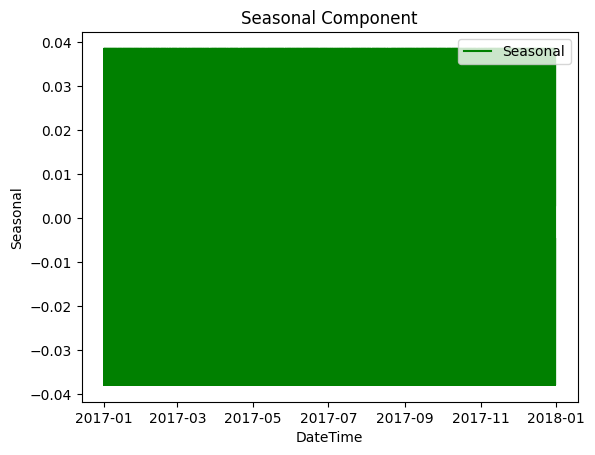

In [55]:
# Se Genera una grafica del componente estacional
plt.plot(data['datetime'], result.seasonal, label='Seasonal', color='green')
plt.title('Seasonal Component')
plt.xlabel('DateTime')
plt.ylabel('Seasonal')
plt.legend()

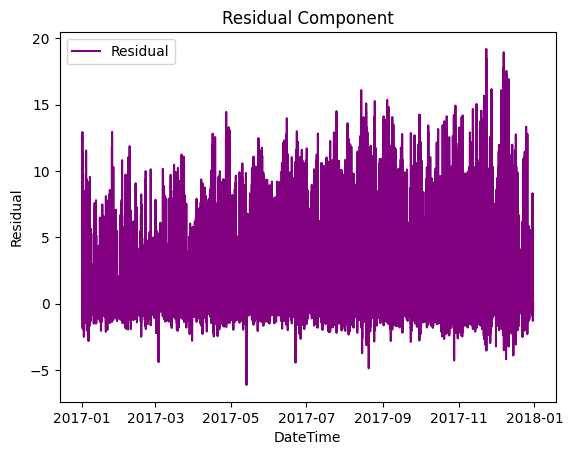

In [56]:
# Se Genera una grafica del componente residual
plt.plot(data['datetime'], result.resid, label='Residual', color='purple')
plt.title('Residual Component')
plt.xlabel('DateTime')
plt.ylabel('Residual')
plt.legend()

# **Parte 4**. Entrenando y Evaluando el Modelo

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings

from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression  # <-- Modelo Añadido
from sklearn.ensemble import RandomForestRegressor  # <-- Modelo Añadido

from statsmodels.tsa.api import VAR
from scipy.stats import randint, uniform

In [58]:
import pandas as pd
import numpy as np

def create_ml_features(df, variable_objetivo):
    """
    Crea las características de series de tiempo para todos los modelos de ML.
    (Esta es la función `_create_ml_features` de la clase anterior)
    """
    df_copy = df.copy()
    
    # Características de Fecha/Hora
    df_copy['hora'] = df_copy.index.hour
    df_copy['minuto'] = df_copy.index.minute
    df_copy['dia_de_semana'] = df_copy.index.dayofweek
    df_copy['dia_del_ano'] = df_copy.index.dayofyear
    
    # Parámetros de alta frecuencia
    pasos_por_hora = 6
    pasos_por_dia = 24 * pasos_por_hora
    
    # Rezagos y Ventanas Móviles (solo de la variable objetivo)
    df_copy[f'lag_{variable_objetivo}_1_hora'] = df_copy[variable_objetivo].shift(pasos_por_hora)
    df_copy[f'lag_{variable_objetivo}_24_horas'] = df_copy[variable_objetivo].shift(pasos_por_dia)
    df_copy[f'rolling_mean_{variable_objetivo}_1_hora'] = df_copy[variable_objetivo].shift(1).rolling(window=pasos_por_hora).mean()
    df_copy[f'rolling_mean_{variable_objetivo}_24_horas'] = df_copy[variable_objetivo].shift(1).rolling(window=pasos_por_dia).mean()
    
    df_copy = df_copy.dropna()
    
    X = df_copy.drop(columns=[variable_objetivo])
    y = df_copy[variable_objetivo]
    
    return X, y

def predict_recursive_ml(model, df_historico, n_pasos, variable_objetivo, warmup_steps=200):
    """
    Realiza una predicción recursiva para CUALQUIER modelo en un pipeline de sklearn.
    """
    df_recursivo = df_historico.copy()
    predicciones = []

    for i in range(n_pasos):
        datos_para_features = df_recursivo.tail(warmup_steps)
        
        X_nuevas, _ = create_ml_features(datos_para_features, variable_objetivo)
        X_a_predecir = X_nuevas.tail(1)
        
        prediccion_actual = model.predict(X_a_predecir)[0]
        predicciones.append(prediccion_actual)
        
        siguiente_fecha = df_recursivo.index[-1] + pd.Timedelta(minutes=10)
        
        nueva_fila = {col: df_recursivo[col].iloc[-1] for col in df_recursivo.columns if col != variable_objetivo}
        nueva_fila[variable_objetivo] = prediccion_actual
        
        df_nueva_fila = pd.DataFrame([nueva_fila], index=[siguiente_fecha])
        df_recursivo = pd.concat([df_recursivo, df_nueva_fila])

    fechas_prediccion = pd.date_range(start=df_historico.index[-1] + pd.Timedelta(minutes=10), periods=n_pasos, freq='10T')
    return pd.Series(predicciones, index=fechas_prediccion, name='predicciones_futuras')

In [59]:
# Importaciones necesarias para esta clase
from statsmodels.tsa.api import VAR
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

class VARModel:
    
    def __init__(self):
        self.model_fit = None
        self.best_lag = 0
        print("Instancia de VARModel creada.")

    def train(self, train_df, max_lags=10, n_splits=5):
        """
        Encuentra el mejor rezago ('p') usando validación cruzada y entrena
        el modelo final en todos los datos de entrenamiento.
        """
        print("Entrenando modelo VAR...")
        best_score = float('inf')
        best_lag_found = 0

        for p in range(1, max_lags + 1):
            scores = []
            tscv = TimeSeriesSplit(n_splits=n_splits)
            try:
                for train_index, test_index in tscv.split(train_df):
                    train_data = train_df.iloc[train_index]
                    test_data = train_df.iloc[test_index]
                    if len(train_data) < p: continue
                    
                    model = VAR(train_data)
                    model_fit_cv = model.fit(maxlags=p)
                    lag_order = model_fit_cv.k_ar
                    forecast_input = train_data.values[-lag_order:]
                    predictions = model_fit_cv.forecast(y=forecast_input, steps=len(test_data))
                    error = mean_squared_error(test_data.values, predictions)
                    scores.append(error)
                
                mean_score = np.mean(scores)
                if mean_score < best_score:
                    best_score = mean_score
                    best_lag_found = p
            except Exception as e:
                continue
        
        print(f"Mejor rezago para VAR: {best_lag_found}")
        
        final_model = VAR(train_df)
        self.model_fit = final_model.fit(maxlags=best_lag_found)
        self.best_lag = self.model_fit.k_ar
        print("Modelo VAR entrenado.")

    def predict(self, train_df, n_steps):
        """
        Realiza una predicción de n_steps usando el historial de train_df.
        """
        if self.model_fit is None:
            raise Exception("El modelo VAR no ha sido entrenado. Llama a .train() primero.")
            
        forecast_input = train_df.values[-self.best_lag:]
        prediccion = self.model_fit.forecast(y=forecast_input, steps=n_steps)
        
        df_prediccion = pd.DataFrame(
            prediccion, 
            index=pd.date_range(start=train_df.index[-1] + pd.Timedelta(minutes=10), periods=n_steps, freq='10min'),
            columns=train_df.columns
        )
        return df_prediccion

In [60]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform

class RandomForestModel:
    
    def __init__(self):
        self.rf_model = None
        self.target_col = None
        self.weather_cols = None
        print("Instancia de RandomForestModel creada.")

    def train(self, train_df, target_col, weather_cols, n_iter=20, n_splits=5):
        """
        Entrena el modelo usando RandomizedSearchCV directamente.
        """
        print(f"Entrenando Random Forest para: {target_col}...")
        self.target_col = target_col
        self.weather_cols = weather_cols

        # 1. Definir el modelo base
        rf_model_base = RandomForestRegressor(n_jobs=-1, random_state=42)
        
        # 2. Definir distribuciones de parámetros
        param_distribuciones_rf = {
            'n_estimators': randint(50, 500),
            'max_depth': randint(3, 15),
            'max_features': uniform(0.3, 0.7),
            'min_samples_leaf': randint(2, 10)
        }
        
        # 3. Preparar datos
        input_df = train_df[self.weather_cols + [self.target_col]]
        X_train_feat, y_train_feat = create_ml_features(input_df, self.target_col)
        
        # 4. Ejecutar Búsqueda Aleatoria
        tscv = TimeSeriesSplit(n_splits=n_splits)
        random_search = RandomizedSearchCV(
            estimator=rf_model_base,
            param_distributions=param_distribuciones_rf,
            n_iter=n_iter,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            verbose=0,
            random_state=1234
        )
        
        random_search.fit(X_train_feat, y_train_feat)
        
        # 5. Guardar el mejor modelo
        self.rf_model = random_search.best_estimator_
        print(f"  -> RF entrenado. Mejor RMSE (CV): {-random_search.best_score_:.4f}")

    def predict(self, train_df, n_steps):
        """
        Realiza una predicción recursiva de n_steps.
        """
        if self.rf_model is None:
            raise Exception("El modelo Random Forest no ha sido entrenado. Llama a .train() primero.")
            
        input_df_hist = train_df[self.weather_cols + [self.target_col]]
        
        return predict_recursive_ml(
            model=self.rf_model,
            df_historico=input_df_hist,
            n_pasos=n_steps,
            variable_objetivo=self.target_col
        )

In [61]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform

class XGBoostModel:
    
    def __init__(self):
        self.xgb_model = None
        self.target_col = None
        self.weather_cols = None
        print("Instancia de XGBoostModel creada.")

    def train(self, train_df, target_col, weather_cols, n_iter=20, n_splits=5):
        """
        Entrena el modelo usando RandomizedSearchCV directamente.
        """
        print(f"Entrenando XGBoost para: {target_col}...")
        self.target_col = target_col
        self.weather_cols = weather_cols

        # 1. Definir el modelo base
        xgb_model_base = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse', n_jobs=-1, random_state=42)
        
        # 2. Definir distribuciones de parámetros
        param_distribuciones_xgb = {
            'n_estimators': randint(100, 1000),
            'max_depth': randint(3, 10),
            'learning_rate': uniform(0.01, 0.2),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4)
        }
        
        # 3. Preparar datos
        input_df = train_df[self.weather_cols + [self.target_col]]
        X_train_feat, y_train_feat = create_ml_features(input_df, self.target_col)
        
        # 4. Ejecutar Búsqueda Aleatoria
        tscv = TimeSeriesSplit(n_splits=n_splits)
        random_search = RandomizedSearchCV(
            estimator=xgb_model_base,
            param_distributions=param_distribuciones_xgb,
            n_iter=n_iter,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            verbose=0,
            random_state=1234
        )
        
        random_search.fit(X_train_feat, y_train_feat)
        
        # 5. Guardar el mejor modelo
        self.xgb_model = random_search.best_estimator_
        print(f"  -> XGBoost entrenado. Mejor RMSE (CV): {-random_search.best_score_:.4f}")

    def predict(self, train_df, n_steps):
        """
        Realiza una predicción recursiva de n_steps.
        """
        if self.xgb_model is None:
            raise Exception("El modelo XGBoost no ha sido entrenado. Llama a .train() primero.")
            
        input_df_hist = train_df[self.weather_cols + [self.target_col]]
        
        return predict_recursive_ml(
            model=self.xgb_model,
            df_historico=input_df_hist,
            n_pasos=n_steps,
            variable_objetivo=self.target_col
        )

In [62]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

class LSTMModel:
    
    def __init__(self):
        self.model = None
        # Scalers separados para X (features) e y (target)
        self.scaler_x = MinMaxScaler(feature_range=(0, 1))
        self.scaler_y = MinMaxScaler(feature_range=(0, 1))
        
        self.n_steps_in = 144
        self.n_features = 0
        self.target_col = None
        self.feature_names = None
        self.weather_cols = None
        
        tf.random.set_seed(42)
        np.random.seed(42)
        
        print("Instancia de LSTMModel creada (con escalado interno).")

    def _create_sequences(self, data):

        X, y = [], []
        
        # El índice del objetivo siempre será el último
        target_idx = -1 
        
        for i in range(len(data)):
            end_ix = i + self.n_steps_in
            if end_ix > len(data) - 1:
                break
            
            # La entrada X son todas las features
            seq_x = data[i:end_ix, :] 
            
            # La salida y es el último valor (target) en el paso end_ix
            seq_y = data[end_ix, target_idx] 
            
            X.append(seq_x)
            y.append(seq_y)
            
        return np.array(X), np.array(y)

    def train(self, train_df, target_col, weather_cols, n_steps_in=144, epochs=20, batch_size=32):

        print(f"Entrenando LSTM para: {target_col}...")
        self.target_col = target_col
        self.weather_cols = weather_cols
        self.n_steps_in = n_steps_in
        # El orden es crucial: primero 'X' (weather), luego 'y' (target)
        self.feature_names = self.weather_cols + [self.target_col]
        self.n_features = len(self.feature_names)
        
        # 1. Separar y escalar X e y
        df_train_subset = train_df[self.feature_names]
        data_x = df_train_subset[self.weather_cols]
        data_y = df_train_subset[[self.target_col]] # Doble corchete para mantener forma
        
        scaled_x = self.scaler_x.fit_transform(data_x)
        scaled_y = self.scaler_y.fit_transform(data_y)
        
        # 2. Combinar datos escalados
        # (scaled_x es 2D, scaled_y es 2D, np.hstack los une)
        scaled_data = np.hstack((scaled_x, scaled_y))
        
        # 3. Crear secuencias
        X_train, y_train = self._create_sequences(scaled_data)
        
        if X_train.shape[0] == 0:
            raise ValueError("No se pudieron crear secuencias.")

        # 4. Definir la arquitectura (Optimizada para GPU)
        self.model = Sequential()
        self.model.add(LSTM(
            50, 
            # Se elimina activation='relu' para usar el kernel cuDNN (GPU)
            input_shape=(self.n_steps_in, self.n_features) 
        ))
        self.model.add(Dense(1))
        self.model.compile(optimizer='adam', loss='mean_squared_error')
        
        # 5. Entrenar el modelo
        print(f"  Iniciando entrenamiento LSTM (Epochs: {epochs})...")
        # verbose=1 te mostrará el progreso del entrenamiento
        self.model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1) 
        print(f"  -> LSTM entrenado para {target_col}.")

    def predict(self, train_df, n_steps):

        if self.model is None:
            raise Exception("El modelo LSTM no ha sido entrenado. Llama a .train() primero.")
        
        # 1. Preparar el historial de entrada
        history_df = train_df[self.feature_names].tail(self.n_steps_in)
        
        # 2. Escalar el historial usando los scalers ya ajustados
        history_x = history_df[self.weather_cols]
        history_y = history_df[[self.target_col]]
        
        scaled_history_x = self.scaler_x.transform(history_x)
        scaled_history_y = self.scaler_y.transform(history_y)
        
        current_batch = np.hstack((scaled_history_x, scaled_history_y))
        
        predictions_scaled = []
        
        # 3. Bucle de predicción recursiva
        for _ in range(n_steps):
            input_window = current_batch.reshape((1, self.n_steps_in, self.n_features))
            
            # Predecir un valor escalado (ej. 0.35)
            pred_scaled_y = self.model.predict(input_window, verbose=0)[0][0]
            predictions_scaled.append(pred_scaled_y)
            
            # Crear la nueva fila para el siguiente paso
            # 1. Tomar las últimas features 'X' (escaladas)
            new_row_scaled_x = current_batch[-1, :self.n_features-1]
            
            # 2. Juntarlas con la nueva predicción 'y' (escalada)
            new_row_scaled = np.append(new_row_scaled_x, pred_scaled_y)
            new_row_scaled = new_row_scaled.reshape(1, self.n_features)
            
            # 3. Añadir la nueva fila al buffer y deslizar la ventana
            current_batch = np.append(current_batch, new_row_scaled, axis=0)
            current_batch = current_batch[-self.n_steps_in:, :] # Mantener el tamaño
        
        # 4. --- [PASO CLAVE] INVERTIR EL ESCALADO ---
        # Convertir la lista de predicciones escaladas a un array 2D
        predictions_scaled_array = np.array(predictions_scaled).reshape(-1, 1)
        
        # Usar el scaler_y para volver a la escala original
        final_predictions = self.scaler_y.inverse_transform(predictions_scaled_array)
        
        # 5. Crear y devolver la Serie de Pandas
        dates = pd.date_range(start=train_df.index[-1] + pd.Timedelta(minutes=10), periods=n_steps, freq='10T')
        # .flatten() convierte el array 2D de vuelta a 1D para la Serie
        return pd.Series(final_predictions.flatten(), index=dates, name='predicciones_futuras_lstm')

2025-11-11 19:02:50.380840: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
original_df = pd.read_csv('power_tetouan_city_original.csv')
modified_df = pd.read_csv('power_tetouan_city_modified.csv')
df_clean = cleaned_df.copy()

power_cols = ['zone_1_power_consumption', 'zone_2_power_consumption', 'zone_3_power_consumption']
weather_cols = ['temperature', 'humidity', 'wind_speed', 'general_diffuse_flows', 'diffuse_flows']
all_numeric_cols = weather_cols + power_cols

# 1. Definir la variable datetime como índice
df_clean.set_index("datetime", inplace=True)

# 2. Dividir Datos
train_df, test_df = train_test_split(df_clean, test_size=0.05, shuffle=False)
N_STEPS = 10 
RF_ITER = 10 
XGB_ITER = 10
N_STEPS_IN_LSTM = 144 # Pasos de lookback (24 horas)
EPOCHS_LSTM = 30

# 3. Entrenar Modelo VAR
var_model = VARModel()
var_model.train(train_df, max_lags=10)

# 4. Entrenar Modelos de ML (uno por zona)
rf_models = {}
xgb_models = {}
#lstm_models = {}

for zone in power_cols:
    # Entrenar Random Forest
    rf_models[zone] = RandomForestModel()
    rf_models[zone].train(train_df, zone, weather_cols, n_iter=RF_ITER)
    
    # Entrenar XGBoost
    xgb_models[zone] = XGBoostModel()
    xgb_models[zone].train(train_df, zone, weather_cols, n_iter=XGB_ITER)

#    # Entrenar LSTM
#    lstm_models[zone] = LSTMModel()
#    lstm_models[zone].train(
#        train_df, 
#        zone, 
#        weather_cols, 
#        n_steps_in=N_STEPS_IN_LSTM, 
#        epochs=EPOCHS_LSTM
#    )

print("\n--- TODO EL ENTRENAMIENTO COMPLETADO ---")

# 5. Realizar Predicciones
predictions = {}

# Predicción VAR (produce todas las columnas)
predictions['VAR'] = var_model.predict(train_df, n_steps=N_STEPS)

# Predicciones de ML (juntar las predicciones de cada zona)
rf_preds_df = pd.DataFrame()
xgb_preds_df = pd.DataFrame()
#lstm_preds_df = pd.DataFrame()

for zone in power_cols:
    rf_preds_df[zone] = rf_models[zone].predict(train_df, n_steps=N_STEPS)
    xgb_preds_df[zone] = xgb_models[zone].predict(train_df, n_steps=N_STEPS)
#    lstm_preds_df[zone] = lstm_models[zone].predict(train_df, n_steps=N_STEPS)

predictions['RandomForest'] = rf_preds_df
predictions['XGBoost'] = xgb_preds_df
#predictions['LSTM'] = lstm_preds_df



Instancia de VARModel creada.
Entrenando modelo VAR...
Mejor rezago para VAR: 10
Modelo VAR entrenado.
Instancia de RandomForestModel creada.
Entrenando Random Forest para: zone_1_power_consumption...
  -> RF entrenado. Mejor RMSE (CV): 2201.4344
Instancia de XGBoostModel creada.
Entrenando XGBoost para: zone_1_power_consumption...
  -> XGBoost entrenado. Mejor RMSE (CV): 2216.3094
Instancia de RandomForestModel creada.
Entrenando Random Forest para: zone_2_power_consumption...
  -> RF entrenado. Mejor RMSE (CV): 1309.7294
Instancia de XGBoostModel creada.
Entrenando XGBoost para: zone_2_power_consumption...
  -> XGBoost entrenado. Mejor RMSE (CV): 1382.1974
Instancia de RandomForestModel creada.
Entrenando Random Forest para: zone_3_power_consumption...
  -> RF entrenado. Mejor RMSE (CV): 1617.0262
Instancia de XGBoostModel creada.
Entrenando XGBoost para: zone_3_power_consumption...
  -> XGBoost entrenado. Mejor RMSE (CV): 1746.0430

--- TODO EL ENTRENAMIENTO COMPLETADO ---



--- 6. Evaluación de Desempeño Base ---

Resultados Base para VAR:
  RMSE zone_1_power_consumption: 2325.3963
  RMSE zone_2_power_consumption: 278.5837
  RMSE zone_3_power_consumption: 1026.5265

Resultados Base para RandomForest:
  RMSE zone_1_power_consumption: 1113.9474
  RMSE zone_2_power_consumption: 392.7519
  RMSE zone_3_power_consumption: 1031.1140

Resultados Base para XGBoost:
  RMSE zone_1_power_consumption: 1658.8418
  RMSE zone_2_power_consumption: 517.0800
  RMSE zone_3_power_consumption: 1106.5580

--- 7. Generando Gráficos Comparativos ---


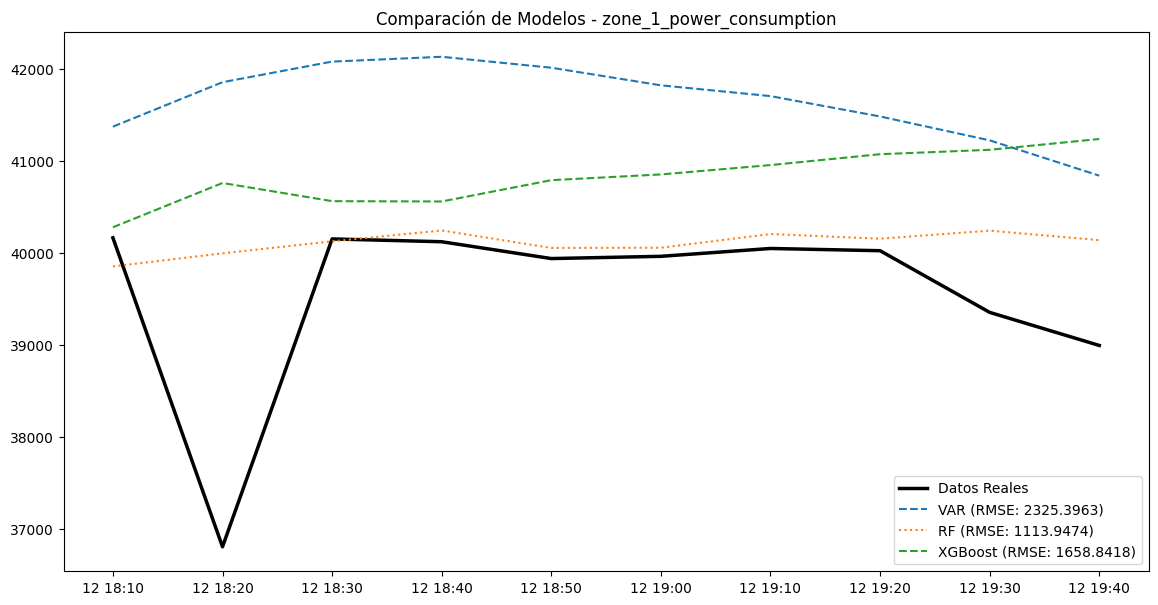

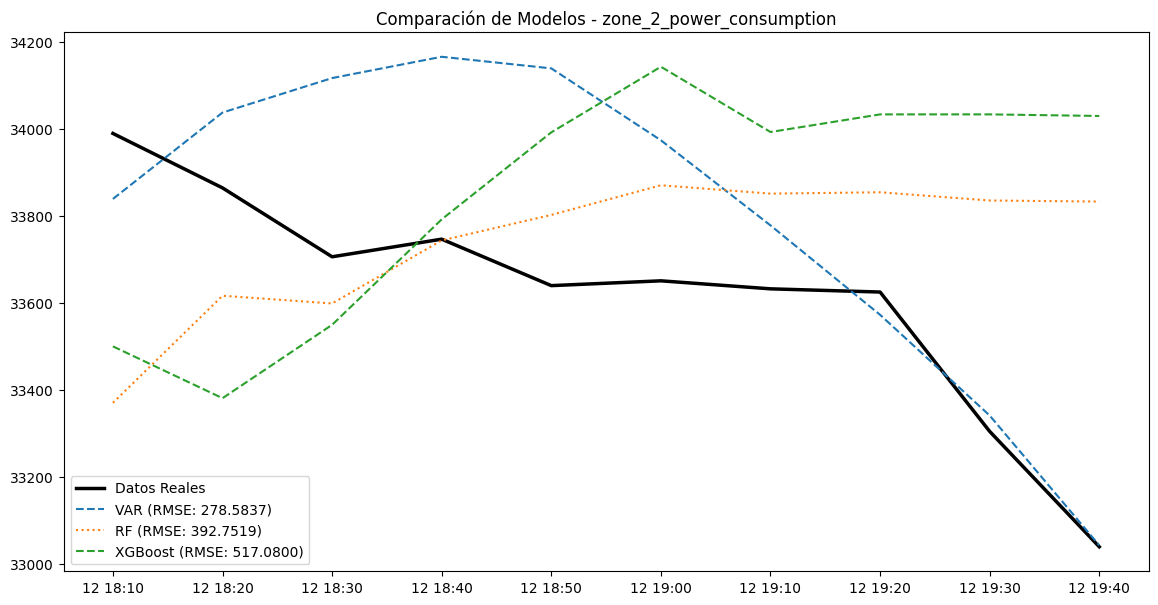

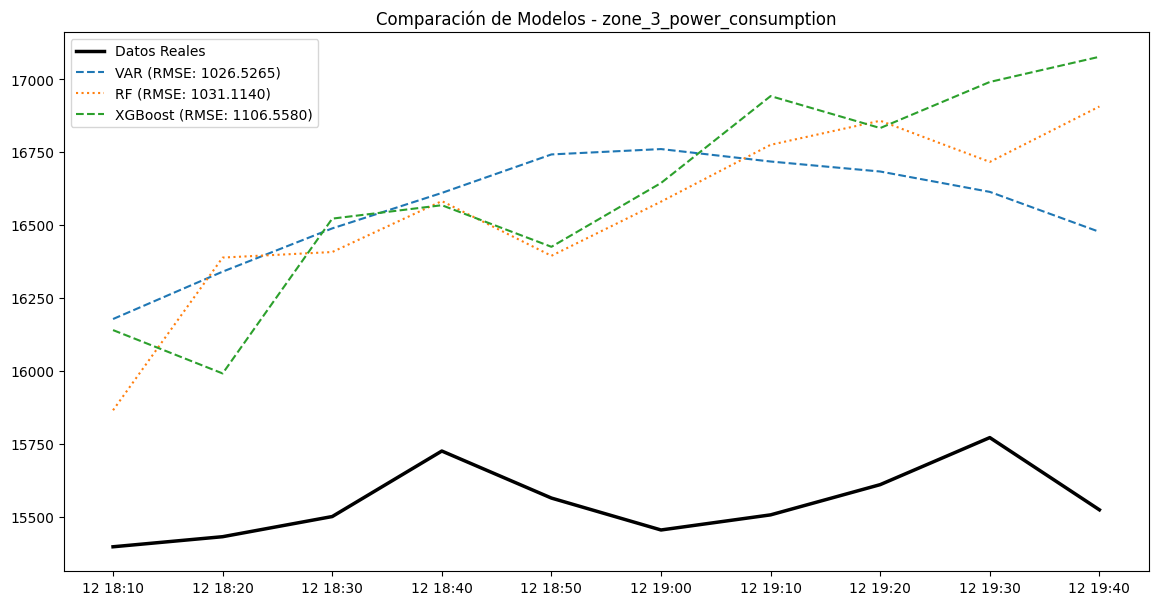

In [69]:
print("\n--- 6. Evaluación de Desempeño Base ---")
baseline_scores = {'VAR': {}, 'RandomForest': {}, 'XGBoost': {}, 'LSTM': {}}
test_data = test_df.head(N_STEPS)

# Calcular todos los RMSE y guardarlos
for zone in power_cols:
    baseline_scores['VAR'][zone] = np.sqrt(mean_squared_error(test_data[zone], predictions['VAR'][zone]))
    baseline_scores['RandomForest'][zone] = np.sqrt(mean_squared_error(test_data[zone], predictions['RandomForest'][zone]))
    baseline_scores['XGBoost'][zone] = np.sqrt(mean_squared_error(test_data[zone], predictions['XGBoost'][zone]))
    # baseline_scores['LSTM'][zone] = np.sqrt(mean_squared_error(test_data[zone], predictions['LSTM'][zone])) # Descomentar para LSTM

# Imprimir el resumen de scores
for model_name, scores in baseline_scores.items():
    if not scores: continue # Saltar si no hay scores (ej. LSTM comentado)
    print(f"\nResultados Base para {model_name}:")
    for zone, rmse in scores.items():
        print(f"  RMSE {zone}: {rmse:.4f}")

# Ahora, el bucle de gráficos solo se encarga de graficar
print("\n--- 7. Generando Gráficos Comparativos ---")
for zone in power_cols:
    plt.figure(figsize=(14, 7))
    plt.plot(test_data.index, test_data[zone], label='Datos Reales', color='black', linewidth=2.5)
    plt.plot(predictions['VAR'].index, predictions['VAR'][zone], label=f"VAR (RMSE: {baseline_scores['VAR'][zone]:.4f})", linestyle='--')
    plt.plot(predictions['RandomForest'].index, predictions['RandomForest'][zone], label=f"RF (RMSE: {baseline_scores['RandomForest'][zone]:.4f})", linestyle=':')
    plt.plot(predictions['XGBoost'].index, predictions['XGBoost'][zone], label=f"XGBoost (RMSE: {baseline_scores['XGBoost'][zone]:.4f})", linestyle='--')
    # plt.plot(predictions['LSTM'].index, predictions['LSTM'][zone], label=f"LSTM (RMSE: {baseline_scores['LSTM'][zone]:.4f})", linestyle='-.', color='purple')
    plt.title(f'Comparación de Modelos - {zone}')
    plt.legend()
    plt.show()

## Evaluación de Data Drift

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

class ModelDriftDetector:
    """
    Clase para simular y evaluar el impacto del Data Drift.
    """
    
    def __init__(self, models_dict, train_df, test_df, baseline_scores, baseline_predictions):
        self.train_df = train_df.copy(deep=True) 
        self.models = models_dict
        self.test_df = test_df
        self.baseline_scores = baseline_scores
        self.baseline_predictions = baseline_predictions
        
        self.drift_report = None
        self.drifted_predictions = None
        self.sensitivity_report = None
        
        self.power_cols = ['zone_1_power_consumption', 'zone_2_power_consumption', 'zone_3_power_consumption']
        self.weather_cols = ['temperature', 'humidity', 'wind_speed', 'general_diffuse_flows', 'diffuse_flows']
        
        print("Instancia de ModelDriftDetector creada (con copias profundas).")

    def _simulate_drift(self, drift_column, drift_type, value, steps_to_drift=144):
        """
        Crea un 'train_df' contaminado.
        """
        print(f"\nSimulando drift: Tipo='{drift_type}', Columna='{drift_column}', Valor='{value}'...")
        
        drifted_train_df = self.train_df.copy(deep=True)
        
        try:
            col_idx = drifted_train_df.columns.get_loc(drift_column)
            target_rows = drifted_train_df.iloc[-steps_to_drift:, col_idx]

            if drift_type == 'mean_shift':
                drifted_train_df.iloc[-steps_to_drift:, col_idx] = target_rows + value
            
            elif drift_type == 'variance_shift':
                # 'value' es la Desviación Estándar del nuevo ruido a añadir
                np.random.seed(42)
                noise = np.random.normal(loc=0, scale=value, size=steps_to_drift)
                drifted_train_df.iloc[-steps_to_drift:, col_idx] = target_rows + noise
            
            elif drift_type == 'stuck_value':
                drifted_train_df.iloc[-steps_to_drift:, col_idx] = value
            
            elif drift_type == 'missing_values':
                np.random.seed(42)
                n_missing = int(steps_to_drift * value)
                missing_indices = np.random.choice(target_rows.index, n_missing, replace=False)
                drifted_train_df.loc[missing_indices, drift_column] = np.nan
            
            elif drift_type == 'linear_trend':
                trend = np.linspace(start=0, stop=value, num=steps_to_drift)
                drifted_train_df.iloc[-steps_to_drift:, col_idx] = target_rows + trend

            else:
                raise ValueError(f"Tipo de drift '{drift_type}' no reconocido.")

        except Exception as e:
            print(f"Error al simular drift: {e}")
            return None
            
        return drifted_train_df

    def _get_drifted_predictions(self, drifted_train_df, n_steps=10):
        """
        Genera predicciones con datos contaminados.
        """
        print("Generando nuevas predicciones con datos contaminados...")
        predictions = {}
        try:
            var_input = drifted_train_df.copy().ffill() 
            predictions['VAR'] = self.models['VAR'].predict(var_input, n_steps=n_steps)
        except Exception as e:
            print(f"Error al predecir con VAR (drift): {e}")

        rf_preds, xgb_preds, lstm_preds = {}, {}, {}
        for zone in self.power_cols:
            input_hist = drifted_train_df[self.weather_cols + [zone]]
            try:
                if 'RandomForest' in self.models:
                    rf_preds[zone] = self.models['RandomForest'][zone].predict(input_hist, n_steps=n_steps)
                if 'XGBoost' in self.models:
                    xgb_preds[zone] = self.models['XGBoost'][zone].predict(input_hist, n_steps=n_steps)
                if 'LSTM' in self.models:
                    lstm_preds[zone] = self.models['LSTM'][zone].predict(input_hist, n_steps=n_steps)
            except Exception as e:
                print(f"Error al predecir {zone} (drift) con ML: {e}")

        if rf_preds: predictions['RandomForest'] = pd.DataFrame(rf_preds)
        if xgb_preds: predictions['XGBoost'] = pd.DataFrame(xgb_preds)
        if lstm_preds: predictions['LSTM'] = pd.DataFrame(lstm_preds)
        
        return predictions

    def run_drift_test(self, drift_column, drift_type, value, n_steps=10, alert_threshold_pct=20.0):
        """
        Ejecuta una simulación de drift y genera un reporte de impacto.
        """
        drifted_train_df = self._simulate_drift(drift_column, drift_type, value)
        if drifted_train_df is None: return
        drifted_predictions = self._get_drifted_predictions(drifted_train_df, n_steps=n_steps)
        self.drifted_predictions = drifted_predictions 

        print("Evaluando el impacto del drift en el desempeño...")
        true_values = self.test_df.head(n_steps)
        report = {}
        for model_name, preds_df in drifted_predictions.items():
            report[model_name] = {}
            for zone in self.power_cols:
                if zone not in preds_df.columns or preds_df[zone].isnull().all():
                    report[model_name][zone] = { "Estado": "Fallo en la predicción (NaNs)" }
                    continue
                baseline_rmse = self.baseline_scores[model_name][zone]
                true_y = true_values[zone]
                pred_y = preds_df[zone]
                new_rmse = np.sqrt(mean_squared_error(true_y, pred_y))
                pct_change = ((new_rmse - baseline_rmse) / baseline_rmse) * 100
                alert_status = "✅ OK"
                action = "N/A"
                if pct_change > alert_threshold_pct:
                    alert_status = f"🚨 ALERTA (Degradación del {pct_change:.1f}%)"
                    action = "Revisar pipeline de features y/o retrain."
                report[model_name][zone] = {"RMSE Base": baseline_rmse, "RMSE (Drift)": new_rmse, "% Cambio": pct_change, "Estado": alert_status, "Acción": action}
        
        self.drift_report = report

    def display_report(self):
        """ Imprime el reporte de drift."""
        if self.drift_report is None: print("No hay reporte para mostrar. Ejecuta .run_drift_test() primero."); return
        print("\n" + "="*50); print("      INFORME DE DETECCIÓN DE DATA DRIFT"); print("="*50)
        for model_name, zones in self.drift_report.items():
            print(f"\n--- Modelo: {model_name} ---")
            for zone, metrics in zones.items():
                print(f"  Zona: {zone}")
                if "Estado" not in metrics: continue
                if metrics["Estado"] == "Fallo en la predicción (NaNs)": print(f"    - Estado: 🚨 {metrics['Estado']}"); continue
                print(f"    - RMSE Base: {metrics['RMSE Base']:.4f}"); print(f"    - RMSE (Drift): {metrics['RMSE (Drift)']:.4f}")
                print(f"    - % Cambio: {metrics['% Cambio']:.2f}%"); print(f"    - Estado: {metrics['Estado']}"); print(f"    - Acción: {metrics['Acción']}")
    
    def plot_drift_impact(self, model_name, zone, n_steps=10):
        """ Genera un gráfico comparativo."""
        print(f"\n--- Generando Gráfico de Impacto de Drift para {model_name} en {zone} ---")
        if self.drift_report is None or self.drifted_predictions is None: print("Error: Ejecuta .run_drift_test() antes de graficar."); return
        if model_name not in self.baseline_predictions or model_name not in self.drifted_predictions: print(f"Error: No se encuentran predicciones base o de drift para el modelo '{model_name}'."); return
        try:
            true_values = self.test_df.head(n_steps)[zone]; base_preds = self.baseline_predictions[model_name][zone]; drift_preds = self.drifted_predictions[model_name][zone]
        except KeyError: print(f"Error: No se pudo encontrar la zona '{zone}' en las predicciones."); return
        try:
            base_rmse = self.drift_report[model_name][zone]['RMSE Base']; drift_rmse = self.drift_report[model_name][zone]['RMSE (Drift)']
        except KeyError: print("Advertencia: No se encontraron scores en el reporte. El gráfico no mostrará el RMSE."); base_rmse = np.nan; drift_rmse = np.nan
        plt.figure(figsize=(14, 7))
        plt.plot(true_values.index, true_values, label='Datos Reales', color='black', linewidth=2.5, marker='o', markersize=5)
        plt.plot(base_preds.index, base_preds, label=f'Predicción Base (RMSE: {base_rmse:.4f})', color='dodgerblue', linestyle='--', linewidth=2)
        plt.plot(drift_preds.index, drift_preds, label=f'Predicción con Drift (RMSE: {drift_rmse:.4f})', color='red', linestyle=':', linewidth=2.5)
        plt.title(f'Impacto del Data Drift en {model_name} para {zone}', fontsize=16, fontweight='bold'); plt.xlabel('Fecha y Hora', fontsize=12); plt.ylabel('Consumo de Energía (kW)', fontsize=12)
        plt.legend(loc='best', fontsize=11); plt.grid(True, which='both', linestyle='--', linewidth=0.5); plt.tight_layout(); plt.show()
    
    def run_sensitivity_analysis(self, drift_type, value, n_steps=10, alert_threshold_pct=20.0):
        """
        Ejecuta un análisis de sensibilidad iterando sobre todas las 'weather_cols'
        usando el 'drift_type' y 'value' especificados.
        """
        print("\n" + "="*60)
        print("      INICIANDO ANÁLISIS DE SENSIBILIDAD DE FEATURES")
        print(f"      (Tipo de Drift: '{drift_type}', Valor: {value})")
        print("="*60)
        
        model_keys = [key for key in self.models.keys() if self.models[key]]
        full_impact_results = {model_name: {zone: {} for zone in self.power_cols} for model_name in model_keys}

        for feature in self.weather_cols:
            
            # 1. Ejecutar UN test de drift para este feature
            self.run_drift_test(
                drift_column=feature,
                drift_type=drift_type,
                value=value,
                n_steps=n_steps,
                alert_threshold_pct=alert_threshold_pct
            )
            
            # 2. Recolectar los resultados de este test
            if self.drift_report is None: continue
            
            for model_name, zones in self.drift_report.items():
                if model_name not in full_impact_results: continue
                for zone, metrics in zones.items():
                    if "Estado" in metrics and metrics["Estado"] == "Fallo en la predicción (NaNs)":
                        full_impact_results[model_name][zone][feature] = -999.0
                    elif "% Cambio" in metrics:
                        full_impact_results[model_name][zone][feature] = metrics["% Cambio"]
        
        # 3. Analizar los resultados recolectados
        self.sensitivity_report = {}
        for model_name, zones in full_impact_results.items():
            self.sensitivity_report[model_name] = {}
            for zone, feature_scores in zones.items():
                if not feature_scores: continue
                
                most_sensitive_feature = max(feature_scores, key=lambda k: abs(feature_scores.get(k)))
                max_impact = feature_scores[most_sensitive_feature]
                
                self.sensitivity_report[model_name][zone] = {
                    "Most Sensitive Feature": most_sensitive_feature,
                    "Impact (% Degradación RMSE)": max_impact,
                    "All Scores (Feature: % Impact)": {f: round(i, 2) for f, i in feature_scores.items()}
                }
        
        print("--- Análisis de Sensibilidad Completado ---")

    def display_sensitivity_report(self):
        """ Imprime el reporte de sensibilidad. (Sin cambios) """
        if not hasattr(self, 'sensitivity_report') or self.sensitivity_report is None:
            print("No hay reporte de sensibilidad. Ejecuta .run_sensitivity_analysis() primero.")
            return

        print("\n" + "="*50)
        print("    INFORME DE SENSIBILIDAD DE VARIABLES")
        print("="*50)
        
        for model_name, zones in self.sensitivity_report.items():
            print(f"\n--- Modelo: {model_name} ---")
            for zone, results in zones.items():
                print(f"  Zona: {zone}")
                print(f"    -> Variable Más Sensible: {results['Most Sensitive Feature']}")
                print(f"       (Impacto: {results['Impact (% Degradación RMSE)']:.2f}%)")
                print(f"    - Detalles: {results['All Scores (Feature: % Impact)']}")

## Pruebas de estrés por Variable

In [208]:
all_models = {
#    "VAR": var_model,
    "RandomForest": rf_models,
#    "XGBoost": xgb_models,
    # "LSTM": lstm_models
}

# 1. Inicializa el detector con los modelos y los scores base
detector = ModelDriftDetector(
    models_dict=all_models,
    train_df=train_df,
    test_df=test_df,
    baseline_scores=baseline_scores,
    baseline_predictions=predictions
)

Instancia de ModelDriftDetector creada (con copias profundas).



Simulando drift: Tipo='variance_shift', Columna='temperature', Valor='15'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

      INFORME DE DETECCIÓN DE DATA DRIFT

--- Modelo: RandomForest ---
  Zona: zone_1_power_consumption
    - RMSE Base: 1113.9474
    - RMSE (Drift): 1125.0494
    - % Cambio: 1.00%
    - Estado: ✅ OK
    - Acción: N/A
  Zona: zone_2_power_consumption
    - RMSE Base: 392.7519
    - RMSE (Drift): 393.6725
    - % Cambio: 0.23%
    - Estado: ✅ OK
    - Acción: N/A
  Zona: zone_3_power_consumption
    - RMSE Base: 1031.1140
    - RMSE (Drift): 1192.9810
    - % Cambio: 15.70%
    - Estado: ✅ OK
    - Acción: N/A

--- Generando Gráfico de Impacto de Drift para RandomForest en zone_1_power_consumption ---


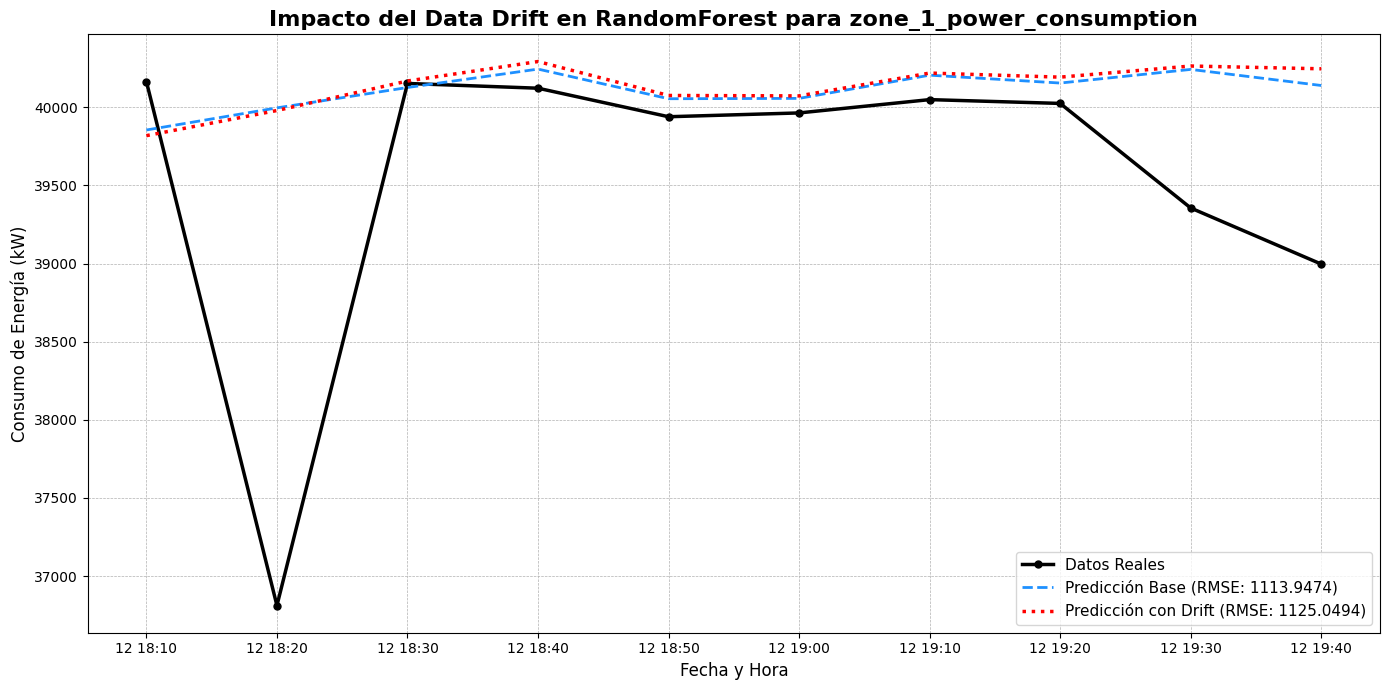


--- Generando Gráfico de Impacto de Drift para RandomForest en zone_2_power_consumption ---


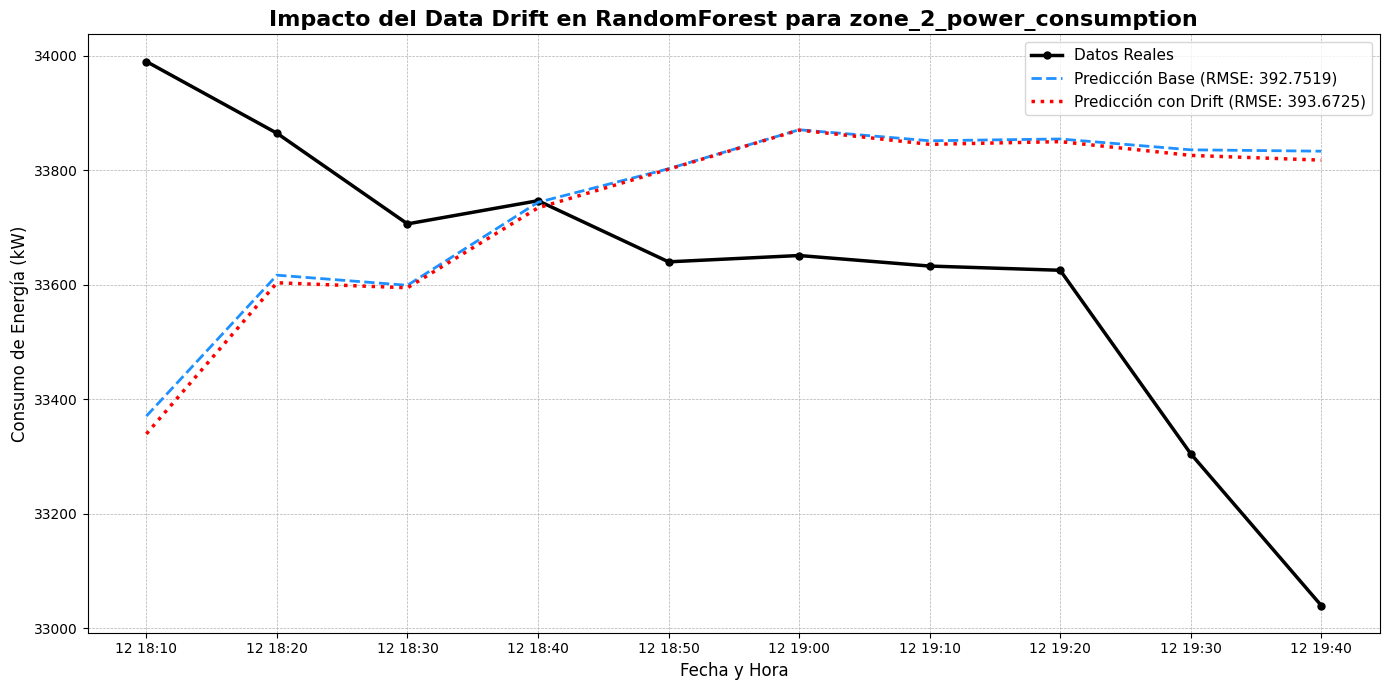


--- Generando Gráfico de Impacto de Drift para RandomForest en zone_3_power_consumption ---


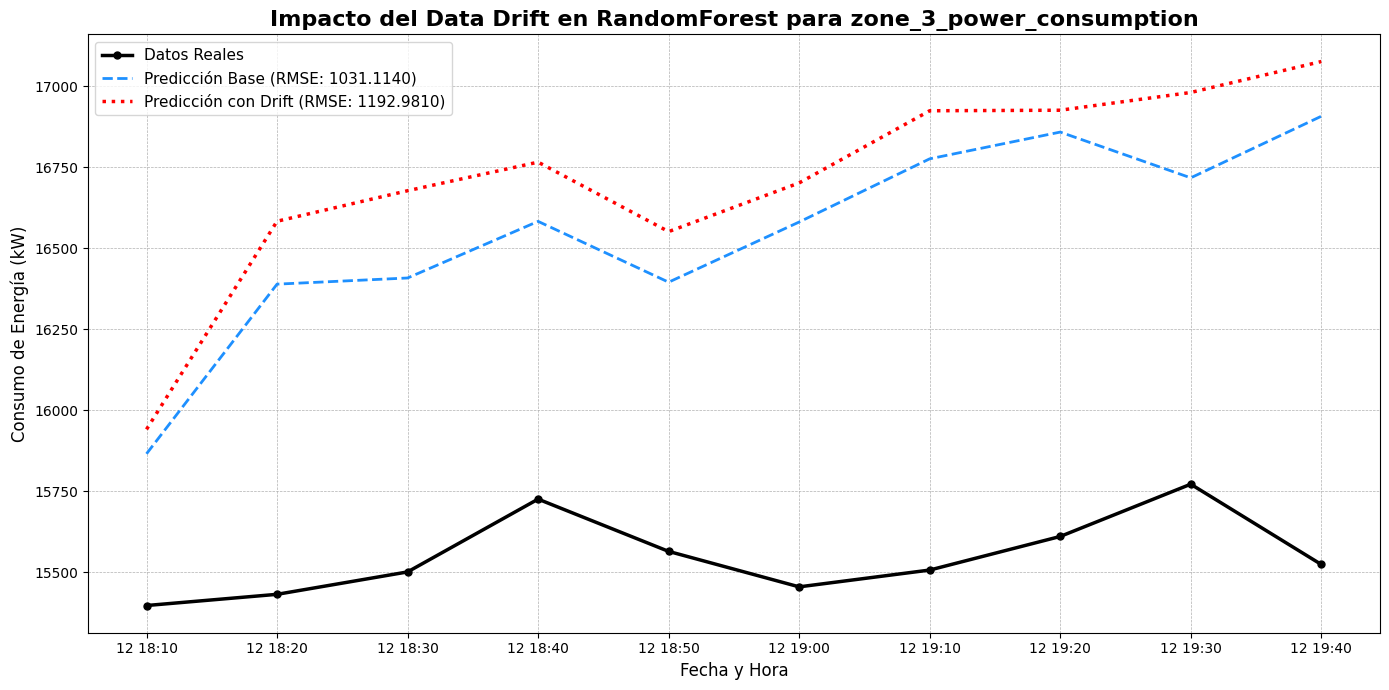

In [209]:
# --- Prueba 1: Aumentar la Varianza de Temperatura
detector.run_drift_test(
    drift_column='temperature',
    drift_type='variance_shift',
    value=15,
    alert_threshold_pct=20.0
)
detector.display_report()

detector.plot_drift_impact(model_name='RandomForest', zone='zone_1_power_consumption')
detector.plot_drift_impact(model_name='RandomForest', zone='zone_2_power_consumption')
detector.plot_drift_impact(model_name='RandomForest', zone='zone_3_power_consumption')


Simulando drift: Tipo='stuck_value', Columna='wind_speed', Valor='1000'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'


Evaluando el impacto del drift en el desempeño...

      INFORME DE DETECCIÓN DE DATA DRIFT

--- Modelo: RandomForest ---
  Zona: zone_1_power_consumption
    - RMSE Base: 1113.9474
    - RMSE (Drift): 1135.4229
    - % Cambio: 1.93%
    - Estado: ✅ OK
    - Acción: N/A
  Zona: zone_2_power_consumption
    - RMSE Base: 392.7519
    - RMSE (Drift): 371.6940
    - % Cambio: -5.36%
    - Estado: ✅ OK
    - Acción: N/A
  Zona: zone_3_power_consumption
    - RMSE Base: 1031.1140
    - RMSE (Drift): 1199.9021
    - % Cambio: 16.37%
    - Estado: ✅ OK
    - Acción: N/A

--- Generando Gráfico de Impacto de Drift para RandomForest en zone_1_power_consumption ---


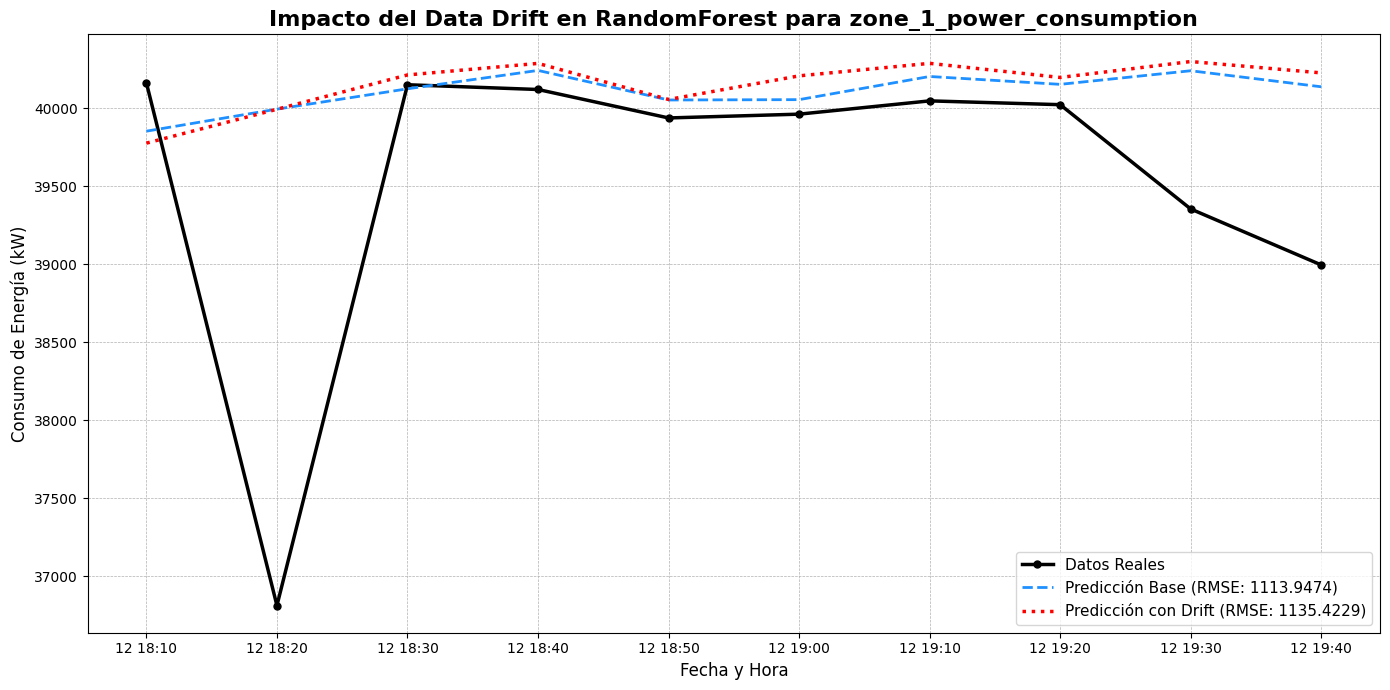


--- Generando Gráfico de Impacto de Drift para RandomForest en zone_2_power_consumption ---


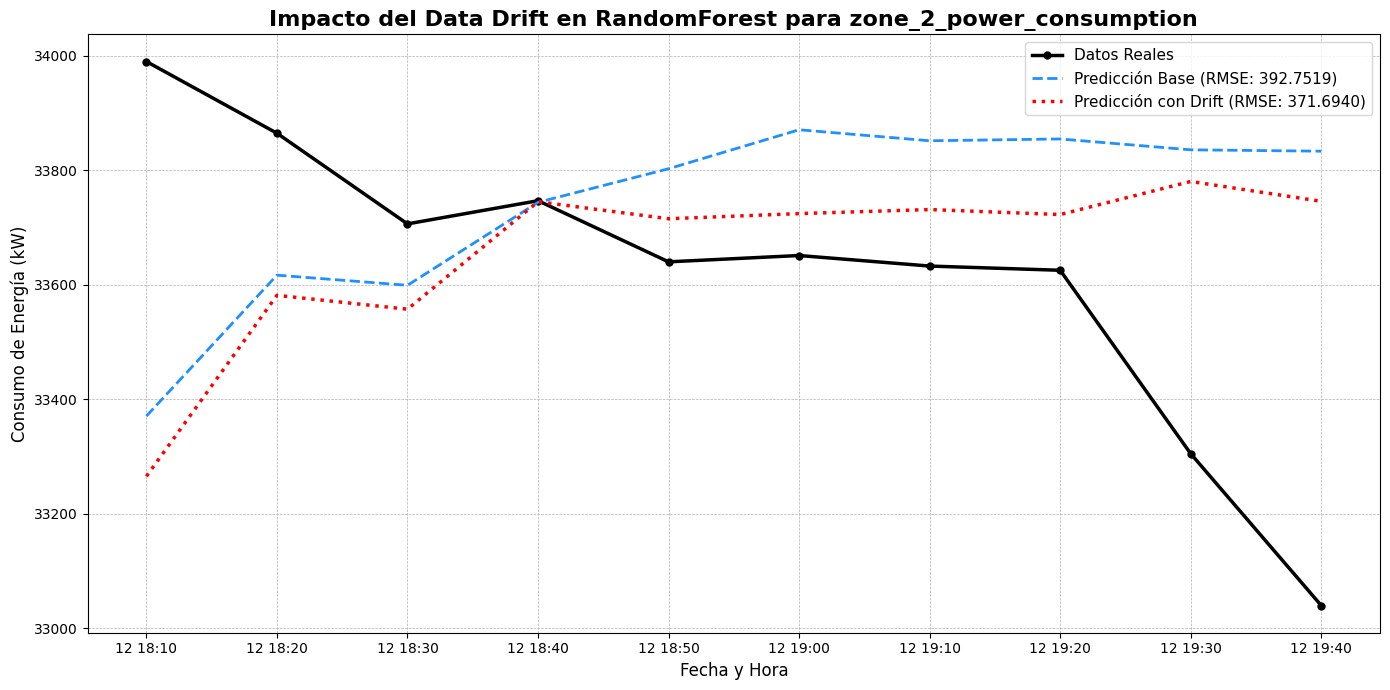


--- Generando Gráfico de Impacto de Drift para RandomForest en zone_3_power_consumption ---


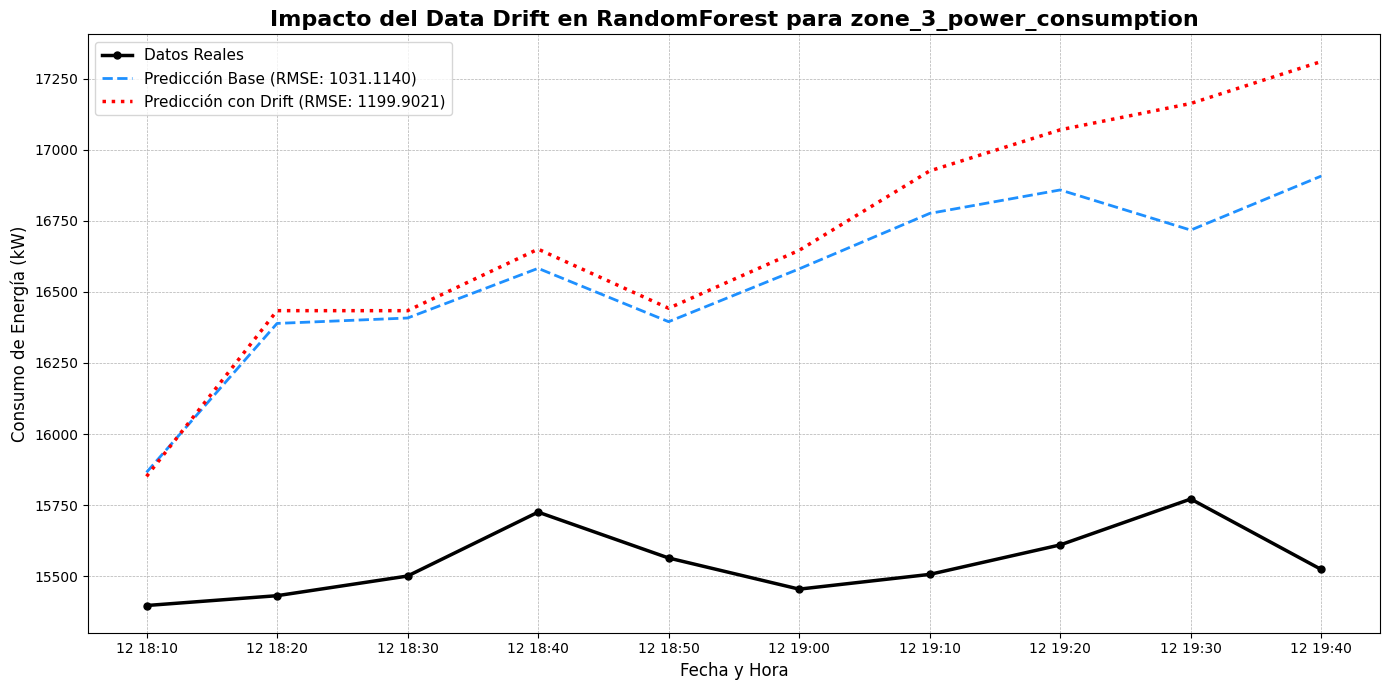

In [210]:
# --- Prueba 2: Sensor de Viento Atascado---
detector.run_drift_test(
    drift_column='wind_speed',
    drift_type='stuck_value',
    value=1000,
    alert_threshold_pct=20.0
)
detector.display_report()

detector.plot_drift_impact(model_name='RandomForest', zone='zone_1_power_consumption')
detector.plot_drift_impact(model_name='RandomForest', zone='zone_2_power_consumption')
detector.plot_drift_impact(model_name='RandomForest', zone='zone_3_power_consumption')




Simulando drift: Tipo='missing_values', Columna='humidity', Valor='0.7'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'


Evaluando el impacto del drift en el desempeño...

      INFORME DE DETECCIÓN DE DATA DRIFT

--- Modelo: RandomForest ---
  Zona: zone_1_power_consumption
    - RMSE Base: 1113.9474
    - RMSE (Drift): 1113.9474
    - % Cambio: -0.00%
    - Estado: ✅ OK
    - Acción: N/A
  Zona: zone_2_power_consumption
    - RMSE Base: 392.7519
    - RMSE (Drift): 392.7519
    - % Cambio: -0.00%
    - Estado: ✅ OK
    - Acción: N/A
  Zona: zone_3_power_consumption
    - RMSE Base: 1031.1140
    - RMSE (Drift): 1031.1140
    - % Cambio: 0.00%
    - Estado: ✅ OK
    - Acción: N/A

--- Generando Gráfico de Impacto de Drift para RandomForest en zone_1_power_consumption ---


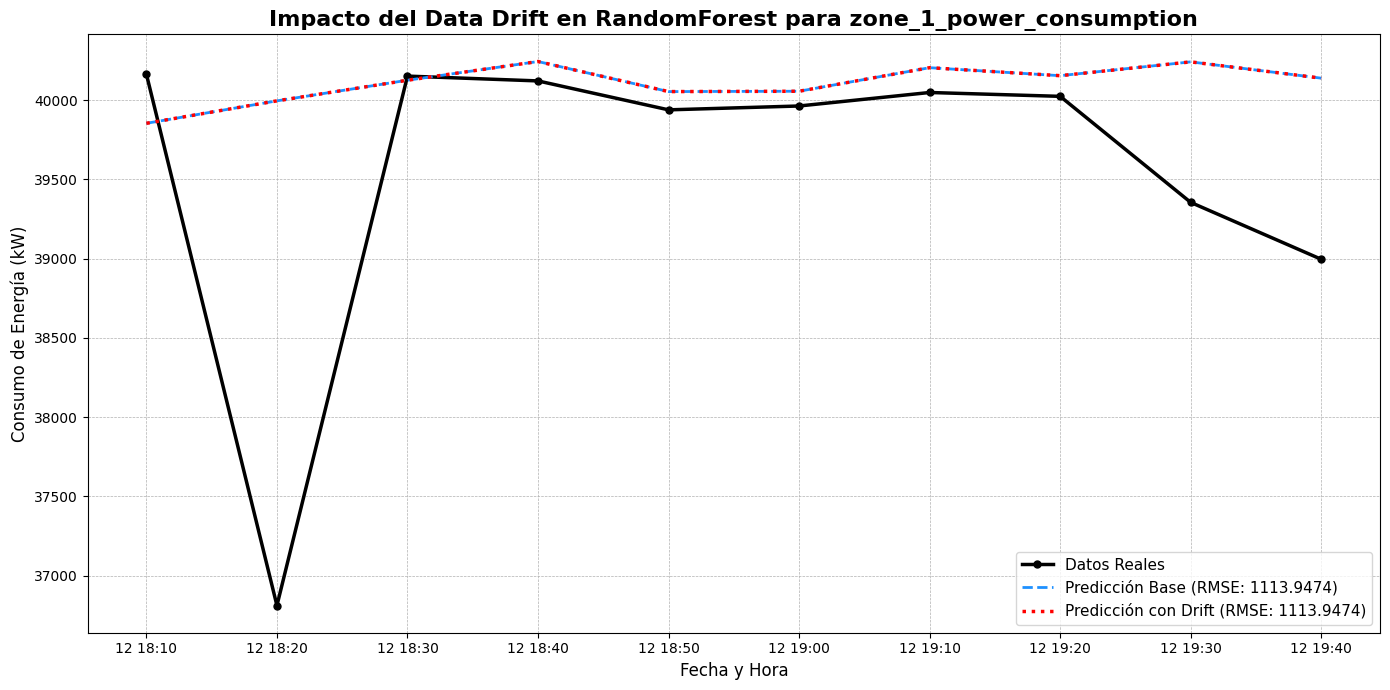


--- Generando Gráfico de Impacto de Drift para RandomForest en zone_2_power_consumption ---


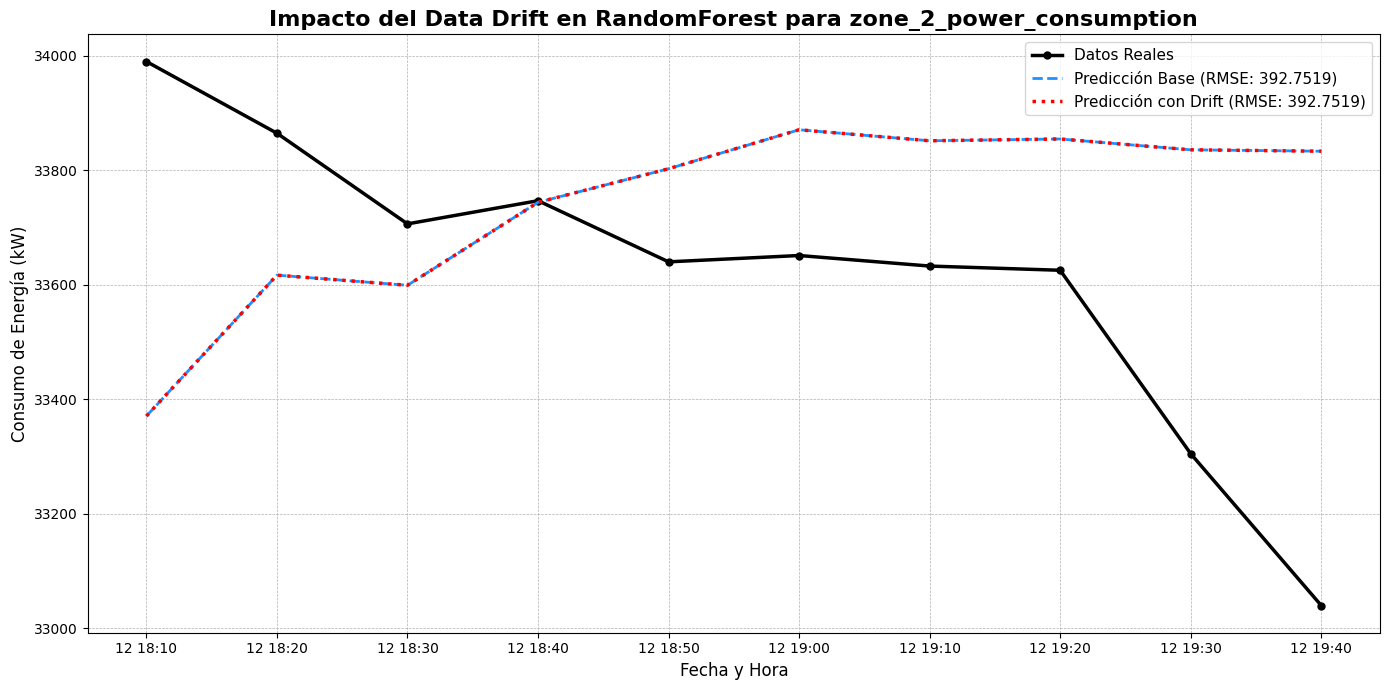


--- Generando Gráfico de Impacto de Drift para RandomForest en zone_3_power_consumption ---


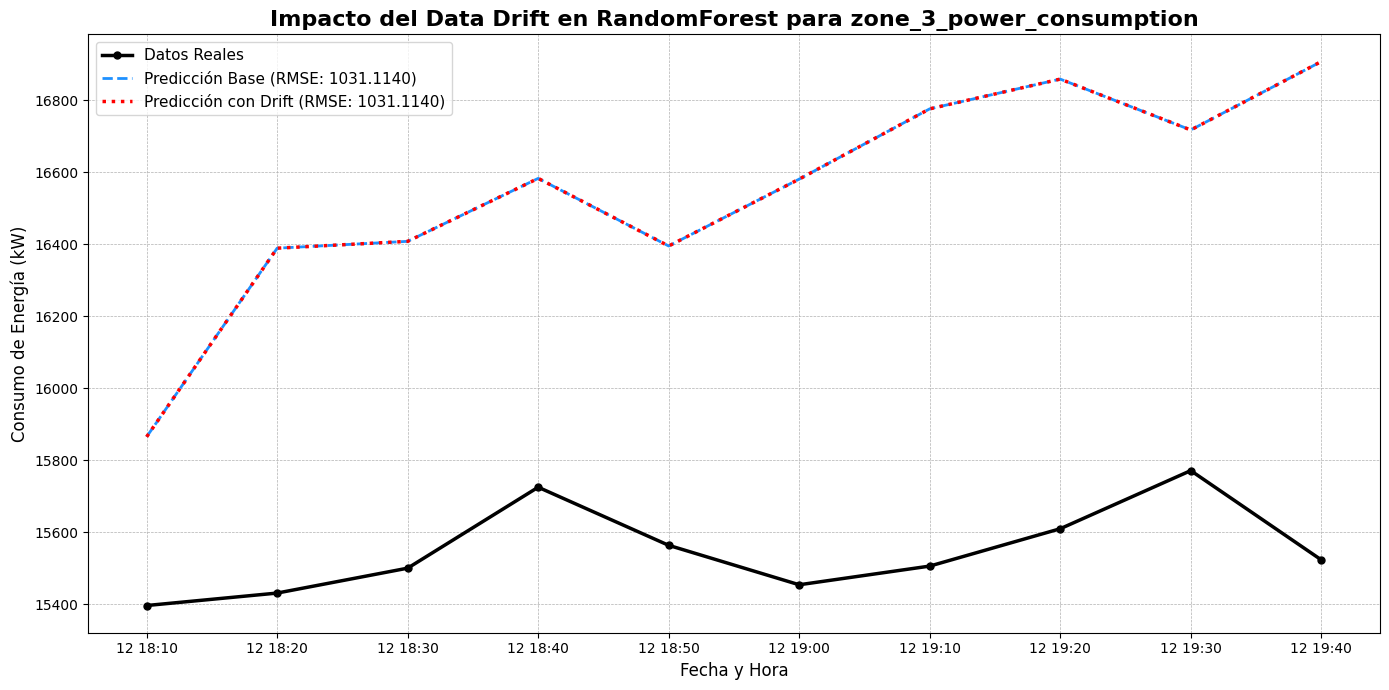

In [211]:
# --- Prueba 3: Nulos en Humedad ---
detector.run_drift_test(
    drift_column='humidity',
    drift_type='missing_values',
    value=0.7, #Porcentaje de nulos en la variable
    alert_threshold_pct=20.0
)
detector.display_report()

detector.plot_drift_impact(model_name='RandomForest', zone='zone_1_power_consumption')
detector.plot_drift_impact(model_name='RandomForest', zone='zone_2_power_consumption')
detector.plot_drift_impact(model_name='RandomForest', zone='zone_3_power_consumption')

# --- [FIN DEL BLOQUE NUEVO] ---


Simulando drift: Tipo='linear_trend', Columna='temperature', Valor='50.0'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

      INFORME DE DETECCIÓN DE DATA DRIFT

--- Modelo: RandomForest ---
  Zona: zone_1_power_consumption
    - RMSE Base: 1113.9474
    - RMSE (Drift): 1160.4817
    - % Cambio: 4.18%
    - Estado: ✅ OK
    - Acción: N/A
  Zona: zone_2_power_consumption
    - RMSE Base: 392.7519
    - RMSE (Drift): 393.0502
    - % Cambio: 0.08%
    - Estado: ✅ OK
    - Acción: N/A
  Zona: zone_3_power_consumption
    - RMSE Base: 1031.1140
    - RMSE (Drift): 1190.6672
    - % Cambio: 15.47%
    - Estado: ✅ OK
    - Acción: N/A

--- Generando Gráfico de Impacto de Drift para RandomForest en zone_1_power_consumption ---


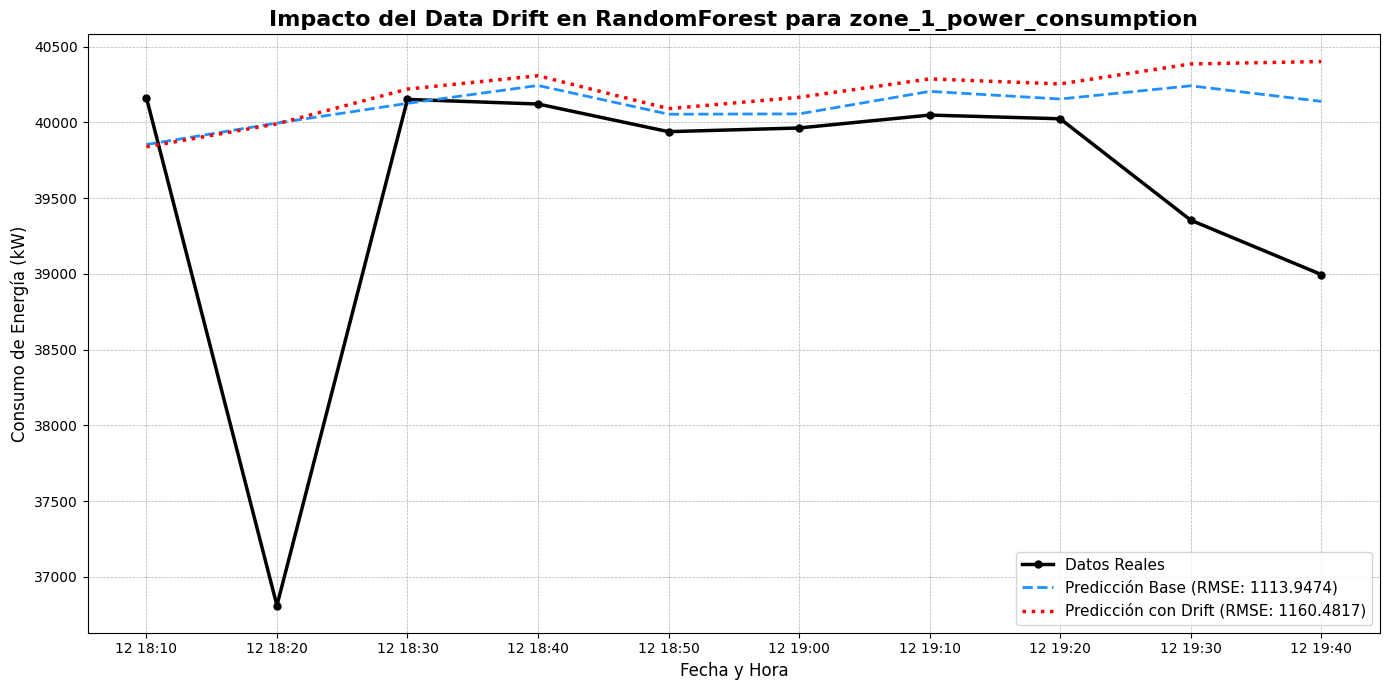


--- Generando Gráfico de Impacto de Drift para RandomForest en zone_2_power_consumption ---


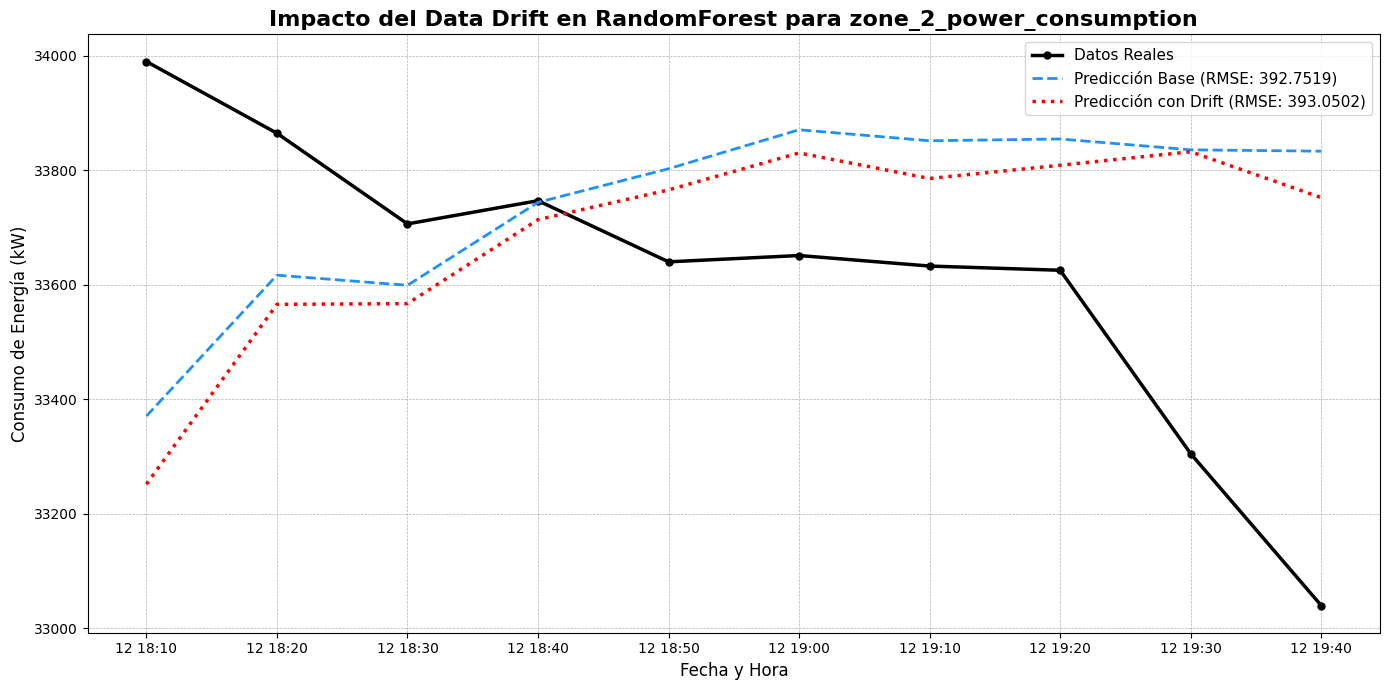


--- Generando Gráfico de Impacto de Drift para RandomForest en zone_3_power_consumption ---


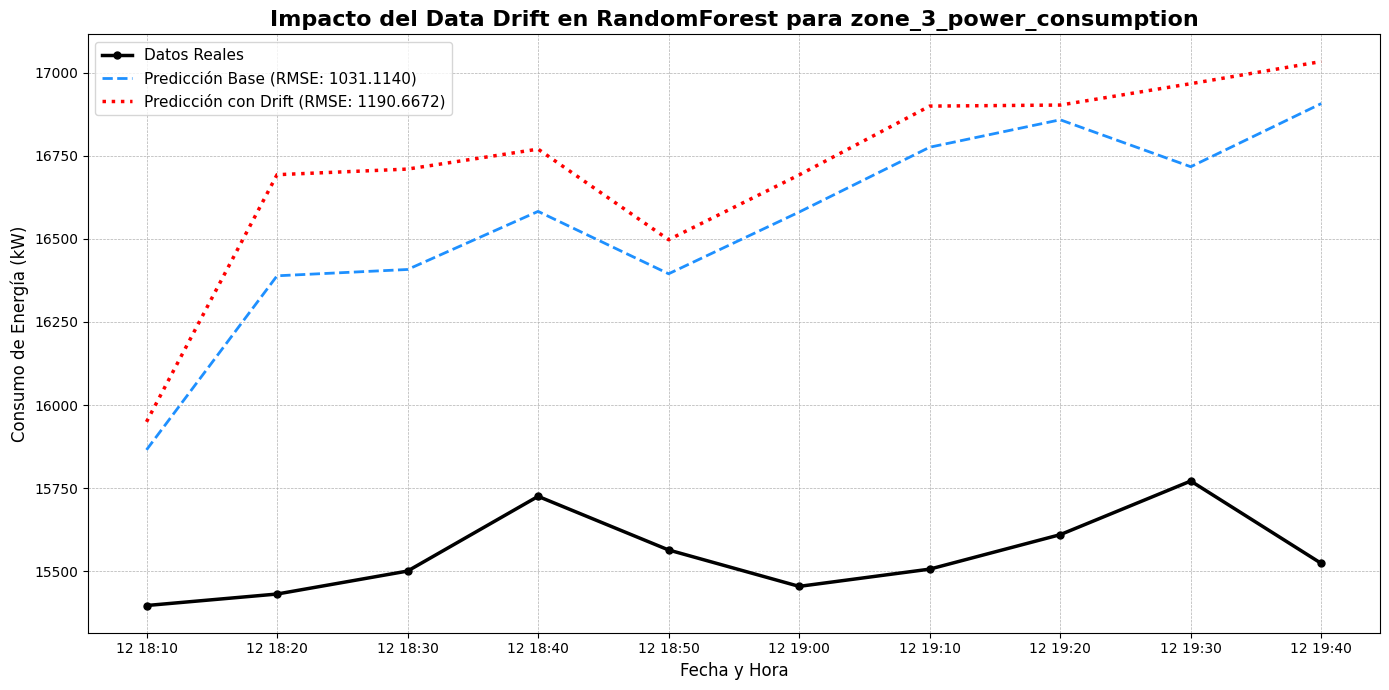

In [212]:
# --- Prueba 4: Descalibración Gradual de Temperatura (+5 grados en 24h) ---
detector.run_drift_test(
    drift_column='temperature',
    drift_type='linear_trend',
    value=50.0,
    alert_threshold_pct=20.0
)
detector.display_report()

detector.plot_drift_impact(model_name='RandomForest',zone='zone_1_power_consumption')
detector.plot_drift_impact(model_name='RandomForest', zone='zone_2_power_consumption')
detector.plot_drift_impact(model_name='RandomForest', zone='zone_3_power_consumption')


## Análisis de sensibilidad de variables

In [213]:
baseline_scores = {'VAR': {}, 'RandomForest': {}, 'XGBoost': {}} #, 'LSTM': {}}
test_data = test_df.head(N_STEPS)

# Calcular todos los RMSE y guardarlos
for zone in power_cols:
    baseline_scores['VAR'][zone] = np.sqrt(mean_squared_error(test_data[zone], predictions['VAR'][zone]))
    baseline_scores['RandomForest'][zone] = np.sqrt(mean_squared_error(test_data[zone], predictions['RandomForest'][zone]))
    baseline_scores['XGBoost'][zone] = np.sqrt(mean_squared_error(test_data[zone], predictions['XGBoost'][zone]))
    # baseline_scores['LSTM'][zone] = np.sqrt(mean_squared_error(test_data[zone], predictions['LSTM'][zone])) # Descomentar para LSTM

# Imprimir el resumen de scores
for model_name, scores in baseline_scores.items():
    if not scores: continue
    print(f"\nResultados Base para {model_name}:")
    for zone, rmse in scores.items():
        print(f"  RMSE {zone}: {rmse:.4f}")


Resultados Base para VAR:
  RMSE zone_1_power_consumption: 2325.3963
  RMSE zone_2_power_consumption: 278.5837
  RMSE zone_3_power_consumption: 1026.5265

Resultados Base para RandomForest:
  RMSE zone_1_power_consumption: 1113.9474
  RMSE zone_2_power_consumption: 392.7519
  RMSE zone_3_power_consumption: 1031.1140

Resultados Base para XGBoost:
  RMSE zone_1_power_consumption: 1658.8418
  RMSE zone_2_power_consumption: 517.0800
  RMSE zone_3_power_consumption: 1106.5580


In [214]:
all_models = {
#    "VAR": var_model,
    "RandomForest": rf_models,
#    "XGBoost": xgb_models,
    # "LSTM": lstm_models
}

# 1. Inicializa el detector
detector = ModelDriftDetector(
    models_dict=all_models,
    train_df=train_df,
    test_df=test_df,
    baseline_scores=baseline_scores,
    baseline_predictions=predictions 
)

# 2. Ejecuta el análisis de sensibilidad
detector.run_sensitivity_analysis(
    drift_type='mean_shift',
    value=5,
    n_steps=N_STEPS
)

# 3. Muestra el reporte de sensibilidad
detector.display_sensitivity_report()

Instancia de ModelDriftDetector creada (con copias profundas).

      INICIANDO ANÁLISIS DE SENSIBILIDAD DE FEATURES
      (Tipo de Drift: 'mean_shift', Valor: 5)

Simulando drift: Tipo='mean_shift', Columna='temperature', Valor='5'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'


Evaluando el impacto del drift en el desempeño...

Simulando drift: Tipo='mean_shift', Columna='humidity', Valor='5'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

Simulando drift: Tipo='mean_shift', Columna='wind_speed', Valor='5'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

Simulando drift: Tipo='mean_shift', Columna='general_diffuse_flows', Valor='5'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

Simulando drift: Tipo='mean_shift', Columna='diffuse_flows', Valor='5'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...
--- Análisis de Sensibilidad Completado ---

    INFORME DE SE

In [215]:
# 2. Ejecuta el análisis de sensibilidad
detector.run_sensitivity_analysis(
    drift_type='variance_shift',
    value=10,
    n_steps=N_STEPS
)

# 3. Muestra el reporte de sensibilidad
detector.display_sensitivity_report()


      INICIANDO ANÁLISIS DE SENSIBILIDAD DE FEATURES
      (Tipo de Drift: 'variance_shift', Valor: 10)

Simulando drift: Tipo='variance_shift', Columna='temperature', Valor='10'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

Simulando drift: Tipo='variance_shift', Columna='humidity', Valor='10'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

Simulando drift: Tipo='variance_shift', Columna='wind_speed', Valor='10'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

Simulando drift: Tipo='variance_shift', Columna='general_diffuse_flows', Valor='10'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el de

In [216]:
# 2. Ejecuta el análisis de sensibilidad
detector.run_sensitivity_analysis(
    drift_type='linear_trend',
    value=10,
    n_steps=N_STEPS
)

# 3. Muestra el reporte de sensibilidad
detector.display_sensitivity_report()


      INICIANDO ANÁLISIS DE SENSIBILIDAD DE FEATURES
      (Tipo de Drift: 'linear_trend', Valor: 10)

Simulando drift: Tipo='linear_trend', Columna='temperature', Valor='10'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

Simulando drift: Tipo='linear_trend', Columna='humidity', Valor='10'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

Simulando drift: Tipo='linear_trend', Columna='wind_speed', Valor='10'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...

Simulando drift: Tipo='linear_trend', Columna='general_diffuse_flows', Valor='10'...
Generando nuevas predicciones con datos contaminados...
Error al predecir con VAR (drift): 'VAR'
Evaluando el impacto del drift en el desempeño...